# Import Library

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Import Data

In [ ]:
df = pd.read_csv('/content/drive/Shareddrives/Học máy trong kinh doanh/Data/DataCoSupplyChainDataset.csv',encoding='latin-1')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [ ]:
print(df['Category Name'].unique())

['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting' 'Baseball & Softball' "Men's Footwear"
 'Camping & Hiking' 'Consumer Electronics' 'Cameras ' 'Computers'
 'Basketball' 'Soccer' "Girls' Apparel" 'Accessories' "Women's Clothing"
 'Crafts' "Men's Clothing" 'Tennis & Racquet' 'Fitness Accessories'
 'As Seen on  TV!' 'Golf Balls' 'Strength Training' "Children's Clothing"
 'Lacrosse' 'Baby ' 'Fishing' 'Books ' 'DVDs' 'CDs ' 'Garden' 'Hockey'
 'Pet Supplies' 'Health and Beauty' 'Music' 'Video Games' 'Golf Gloves'
 'Golf Bags & Carts' 'Golf Shoes' 'Golf Apparel' "Women's Golf Clubs"
 "Men's Golf Clubs" 'Toys' 'Water Sports' 'Indoor/Outdoor Games']


In [ ]:
# Danh sách cột categorical
selected_categorical_features_trong = ['Department Name', 'Category Name', 'Customer State',
                                       'Order Status', 'Order Country', 'Order Region',
                                       'Order State', 'Type', 'Customer City', 'Order City',
                                       'Shipping Mode']

# Danh sách cột numerical
selected_numerical_features_trong = ['Days for shipment (scheduled)',
                                     'Benefit per order', 'Sales per customer',
                                     'Latitude', 'Longitude', 'Order Item Discount Rate',
                                     'Order Item Product Price', 'Order Item Profit Ratio',
                                     'Order Item Quantity']

# Gộp tất cả + cột target + cột ngày
selected_features = (selected_categorical_features_trong +
                     selected_numerical_features_trong +
                     ['Late_delivery_risk', 'order date (DateOrders)'])

# Lọc DataFrame
df_selected = df[selected_features].copy()


In [ ]:
# Giữ lại các dòng không phải CANCELED hoặc SUSPECTED_FRAUD
df_selected = df_selected[~df_selected['Order Status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])]
df_diengiai=df_selected.copy()
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk,order date (DateOrders)
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,91.250000,314.640015,18.251453,-66.037056,0.04,327.750000,0.29,1,0,1/31/2018 22:56
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,-249.089996,311.359985,18.279451,-66.037064,0.05,327.750000,-0.80,1,1,1/13/2018 12:27
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,-247.779999,309.720001,37.292233,-121.881279,0.06,327.750000,-0.80,1,0,1/13/2018 12:06
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,22.860001,304.809998,34.125946,-118.291016,0.07,327.750000,0.08,1,0,1/13/2018 11:45
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,134.210007,298.250000,18.253769,-66.037048,0.09,327.750000,0.45,1,0,1/13/2018 11:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,40.000000,399.980011,40.640930,-73.942711,0.00,399.980011,0.10,1,0,1/16/2016 3:40
180515,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,-613.770019,395.980011,35.362545,-119.018700,0.01,399.980011,-1.55,1,1,1/16/2016 1:34
180516,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,141.110001,391.980011,41.629959,-72.967155,0.02,399.980011,0.36,1,1,1/15/2016 21:00
180517,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,186.229996,387.980011,18.213350,-66.370575,0.03,399.980011,0.48,1,0,1/15/2016 20:18


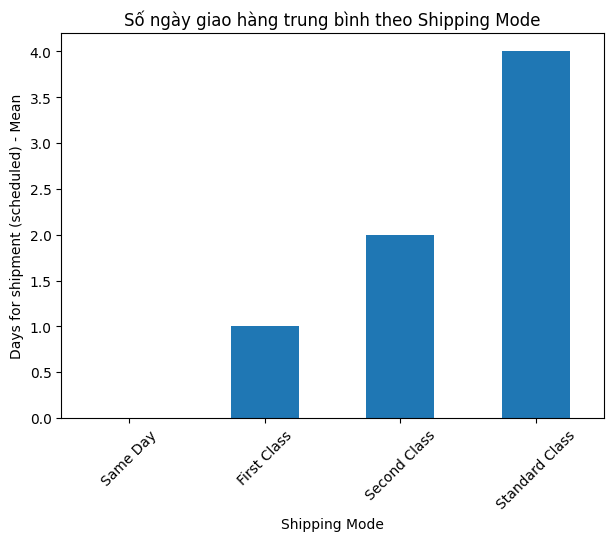

In [ ]:
import matplotlib.pyplot as plt
avg_days = df_selected.groupby('Shipping Mode')['Days for shipment (scheduled)'].mean().sort_values()

plt.figure(figsize=(7,5))
avg_days.plot(kind='bar')
plt.title('Số ngày giao hàng trung bình theo Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Days for shipment (scheduled) - Mean')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df_selected.info())

<class 'pandas.core.frame.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Department Name                172765 non-null  object 
 1   Category Name                  172765 non-null  object 
 2   Customer State                 172765 non-null  object 
 3   Order Status                   172765 non-null  object 
 4   Order Country                  172765 non-null  object 
 5   Order Region                   172765 non-null  object 
 6   Order State                    172765 non-null  object 
 7   Type                           172765 non-null  object 
 8   Customer City                  172765 non-null  object 
 9   Order City                     172765 non-null  object 
 10  Shipping Mode                  172765 non-null  object 
 11  Days for shipment (scheduled)  172765 non-null  int64  
 12  Benefit per order              1727

In [ ]:
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk,order date (DateOrders)
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,91.250000,314.640015,18.251453,-66.037056,0.04,327.750000,0.29,1,0,1/31/2018 22:56
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,-249.089996,311.359985,18.279451,-66.037064,0.05,327.750000,-0.80,1,1,1/13/2018 12:27
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,-247.779999,309.720001,37.292233,-121.881279,0.06,327.750000,-0.80,1,0,1/13/2018 12:06
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,22.860001,304.809998,34.125946,-118.291016,0.07,327.750000,0.08,1,0,1/13/2018 11:45
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,134.210007,298.250000,18.253769,-66.037048,0.09,327.750000,0.45,1,0,1/13/2018 11:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,40.000000,399.980011,40.640930,-73.942711,0.00,399.980011,0.10,1,0,1/16/2016 3:40
180515,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,-613.770019,395.980011,35.362545,-119.018700,0.01,399.980011,-1.55,1,1,1/16/2016 1:34
180516,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,141.110001,391.980011,41.629959,-72.967155,0.02,399.980011,0.36,1,1,1/15/2016 21:00
180517,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,186.229996,387.980011,18.213350,-66.370575,0.03,399.980011,0.48,1,0,1/15/2016 20:18


# Import Pickle to find feature important

In [ ]:
import os
import pickle
import pandas as pd
import gc

model_files = {
    "DecisionTree": "/content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/decisiontree_resampling.pkl",
    "ExtraTrees": "/content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/extratrees_resampling.pkl",
    "RandomForest": "/content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/randomforest_resampling.pkl"
}

models_ros = {}

for name, path in model_files.items():
    print(f"\n Đang load {name} từ {path} ...")

    if not os.path.exists(path):
        print(f" Không tìm thấy file: {path}")
        continue

    try:
        with open(path, "rb") as f:
            pkg = pickle.load(f)
        print(f" File {name} load thành công")

        # Kiểm tra cấu trúc và lấy encoder, scaler, model
        encoder = pkg.get("encoder")
        scaler = pkg.get("scaler")
        model = pkg.get("models", {}).get(name, {}).get("ROS")

        if encoder is None or scaler is None or model is None:
            print(f" Thiếu encoder/scaler/model trong {name}, bỏ qua.")
            continue

        models_ros[name] = {
            "encoder": encoder,
            "scaler": scaler,
            "model": model
        }
        print(f" Loaded {name} ROS hoàn chỉnh")

    except (EOFError, AttributeError, MemoryError, pickle.UnpicklingError) as e:
        print(f" Lỗi khi load {name}: {type(e).__name__} - {e}")
        continue
    except Exception as e:
        print(f" Lỗi không xác định khi load {name}: {e}")
        continue

    del pkg
    gc.collect()


 Đang load DecisionTree từ /content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/decisiontree_resampling.pkl ...
 File DecisionTree load thành công
 Loaded DecisionTree ROS hoàn chỉnh

 Đang load ExtraTrees từ /content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/extratrees_resampling.pkl ...
 File ExtraTrees load thành công
 Loaded ExtraTrees ROS hoàn chỉnh

 Đang load RandomForest từ /content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/randomforest_resampling.pkl ...
 File RandomForest load thành công
 Loaded RandomForest ROS hoàn chỉnh


In [ ]:
import pandas as pd

# Ngưỡng loại bỏ feature ít quan trọng
threshold = 0.01

# Danh sách để lưu feature importance từng model
df_list = []

# Lặp qua từng model
for name, parts in models_ros.items():
    encoder = parts["encoder"]
    model = parts["model"]

    # Lấy tên cột sau OneHotEncoder cho categorical
    encoded_feature_names = encoder.get_feature_names_out(selected_categorical_features_trong)

    # Ghép numeric + categorical
    full_feature_names = list(selected_numerical_features_trong) + list(encoded_feature_names)

    print(f"\n============================")
    print(f" Mô hình: {name}")
    print(f" Tổng số feature sau encode: {len(full_feature_names)}")

    # Kiểm tra độ khớp
    if len(model.feature_importances_) != len(full_feature_names):
        print(f" Số lượng feature không khớp ({len(model.feature_importances_)} vs {len(full_feature_names)})")
        continue

    # Tạo DataFrame feature importance
    df_imp = pd.DataFrame({
        "Feature": full_feature_names,
        name: model.feature_importances_
    })

    df_list.append(df_imp)

    # In top 15
    print(f"\n Top 15 feature quan trọng nhất ({name} - ROS):")
    print(df_imp.sort_values(name, ascending=False).head(15).to_string(index=False))

# Merge tất cả feature importance theo Feature
df_all = df_list[0]
for df in df_list[1:]:
    df_all = pd.merge(df_all, df, on="Feature", how="outer")

# Điền giá trị 0 cho feature không xuất hiện ở model nào đó
df_all = df_all.fillna(0)

# Tính mức trung bình quan trọng
feature_cols = list(models_ros.keys())
df_all['Importance_avg'] = df_all[feature_cols].mean(axis=1)

# Sắp xếp giảm dần theo mức trung bình
df_all = df_all.sort_values('Importance_avg', ascending=False)

# Lọc feature >= threshold
df_selected = df_all[df_all['Importance_avg'] >= threshold]

print("\n============================")
print(f" Danh sách feature sau khi loại bỏ feature ít quan trọng (Importance_avg >= {threshold}):")
print(df_selected.to_string(index=False))


 Mô hình: DecisionTree
 Tổng số feature sau encode: 5520

 Top 15 feature quan trọng nhất (DecisionTree - ROS):
                     Feature  DecisionTree
Shipping Mode_Standard Class      0.195678
                    Latitude      0.071170
                   Longitude      0.056454
   Shipping Mode_First Class      0.037644
  Shipping Mode_Second Class      0.019558
           Benefit per order      0.014993
          Sales per customer      0.014862
     Order Item Profit Ratio      0.012975
    Order Item Discount Rate      0.012133
    Order Item Product Price      0.007273
               Type_TRANSFER      0.005316
                Type_PAYMENT      0.004929
     Order Status_PROCESSING      0.004916
Order Status_PENDING_PAYMENT      0.003995
                  Type_DEBIT      0.003988

 Mô hình: ExtraTrees
 Tổng số feature sau encode: 5520

 Top 15 feature quan trọng nhất (ExtraTrees - ROS):
                      Feature  ExtraTrees
 Shipping Mode_Standard Class    0.078070
    Sh

*   Các nhóm Shipping Mode chiếm  tỉ lệ ảnh hưởng cao nhất ở 3 thuật toán
*   Thời gian giao hàng dự kiến ảnh hưởng đến khả năng giao hàng trễ


*  Nhóm biến Latitude, Longtitude có ảnh hưởng đến khả năng giao hàng trễ bởi vì khoảng cách địa lí của kho ảnh hưởng đến việc giao hàng
*  Nhóm biến giá trị đơn hàng: Benefit per order, Sales per order, Order Item Profit Ratio, Order Item Discount Rate, Order Item Product Price ảnh hưởng đến việc giao trễ





In [ ]:
cols_selected = [
    'Shipping Mode',
    'Days for shipment (scheduled)',
    'Latitude',
    'Longitude',
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Category Name',
    'order date (DateOrders)',
    'Order City',
    'Customer Segment'
]
# Giữ lại các cột đã chọn
df_selected = df[cols_selected]
df_selected

,Shipping Mode,Days for shipment (scheduled),Latitude,Longitude,Benefit per order,Sales per customer,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Category Name,order date (DateOrders),Order City,Customer Segment
0,Standard Class,4,18.251453,-66.037056,91.250000,314.640015,0.04,327.750000,0.29,Sporting Goods,1/31/2018 22:56,Bekasi,Consumer
1,Standard Class,4,18.279451,-66.037064,-249.089996,311.359985,0.05,327.750000,-0.80,Sporting Goods,1/13/2018 12:27,Bikaner,Consumer
2,Standard Class,4,37.292233,-121.881279,-247.779999,309.720001,0.06,327.750000,-0.80,Sporting Goods,1/13/2018 12:06,Bikaner,Consumer
3,Standard Class,4,34.125946,-118.291016,22.860001,304.809998,0.07,327.750000,0.08,Sporting Goods,1/13/2018 11:45,Townsville,Home Office
4,Standard Class,4,18.253769,-66.037048,134.210007,298.250000,0.09,327.750000,0.45,Sporting Goods,1/13/2018 11:24,Townsville,Corporate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Standard Class,4,40.640930,-73.942711,40.000000,399.980011,0.00,399.980011,0.10,Fishing,1/16/2016 3:40,Shanghái,Home Office
180515,Second Class,2,35.362545,-119.018700,-613.770019,395.980011,0.01,399.980011,-1.55,Fishing,1/16/2016 1:34,Hirakata,Corporate
180516,Standard Class,4,41.629959,-72.967155,141.110001,391.980011,0.02,399.980011,0.36,Fishing,1/15/2016 21:00,Adelaide,Corporate
180517,Standard Class,4,18.213350,-66.370575,186.229996,387.980011,0.03,399.980011,0.48,Fishing,1/15/2016 20:18,Adelaide,Consumer


Tính Category theo ngày của từng phương thức để số dòng dữ liệu để đưa data giảm bớt sự imbanlance , đưa data về trạng thái cân bằng hơn để thực hiện phân cụm



*   Latitude, long titude lấy dạng list để sau dễ trực quan
*   Sale per customer, Benefit per order liên quan đến nhà quản trị, nên tính theo ngày để xem doanh thu như nào




In [ ]:
import pandas as pd
# 1. Chuyển cột ngày sang datetime
df_selected['order date (DateOrders)'] = pd.to_datetime(
    df_selected['order date (DateOrders)'],
    format='%m/%d/%Y %H:%M'
)
# 2. Tạo cột ngày (chỉ lấy ngày, không lấy giờ)
df_selected['Day'] = df_selected['order date (DateOrders)'].dt.date

# 3. Group by theo ngày + Category Name + Shipping Mode
#    → Lưu toàn bộ danh sách tọa độ thay vì lấy trung bình
df_agg = df_selected.groupby(['Day', 'Category Name', 'Shipping Mode']).agg({
    'Days for shipment (scheduled)': 'mean',
    'Benefit per order': 'sum',
    'Sales per customer': 'sum',
    'Latitude': list,     # giữ danh sách tất cả vĩ độ trong nhóm
    'Longitude': list,   # giữ danh sách tất cả kinh độ trong nhóm
    'Order City':list,
    'Customer Segment':list
}).reset_index()

# Sao lưu sang df_phancum
df_phancum = df_agg.copy()
df_phancum

/tmp/ipython-input-1925544806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['order date (DateOrders)'] = pd.to_datetime(
/tmp/ipython-input-1925544806.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Day'] = df_selected['order date (DateOrders)'].dt.date


,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment
0,2015-01-01,Accessories,First Class,1.0,3.600000,59.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer]
1,2015-01-01,Accessories,Second Class,2.0,6.600000,87.959999,[35.1572609],[-89.78952789],[Mexico City],[Corporate]
2,2015-01-01,Accessories,Standard Class,4.0,15.150000,83.459999,"[29.52001, 40.76358032]","[-98.63741303, -73.83003998]","[Dos Quebradas, Santo Domingo]","[Home Office, Consumer]"
3,2015-01-01,Baseball & Softball,First Class,1.0,6.720000,55.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer]
4,2015-01-01,Camping & Hiking,First Class,1.0,104.469994,788.950028,"[36.05979919, 18.27436447, 33.97929382]","[-86.67125702, -66.37054443, -118.289093]","[Madero, San Juan del Río, Tegucigalpa]","[Consumer, Consumer, Consumer]"
...,...,...,...,...,...,...,...,...,...,...
40891,2018-01-31,Toys,Standard Class,4.0,1.530000,10.910000,[41.83079147],[-87.80297852],[Bekasi],[Corporate]
40892,2018-01-31,Video Games,Same Day,0.0,9.790000,34.980000,[25.86028481],[-80.19734192],[Gold Coast],[Corporate]
40893,2018-01-31,Women's Clothing,First Class,1.0,203.160000,1733.040009,"[18.21002388, 40.67771912, 43.60348129, 33.521...","[-66.0370636, -73.96311951, -84.78716278, -82....","[Singapur, Orange, Aurangabad, Bekasi, Delhi, ...","[Home Office, Consumer, Corporate, Consumer, H..."
40894,2018-01-31,Women's Clothing,Second Class,2.0,-381.270005,3228.680008,"[18.23366928, 18.23006058, 40.41231918, 38.687...","[-66.0370636, -66.03705597, -104.6923523, -77....","[Srinagar, Pekín, Tasikmalaya, Srinagar, Jodhp...","[Consumer, Consumer, Consumer, Corporate, Cons..."


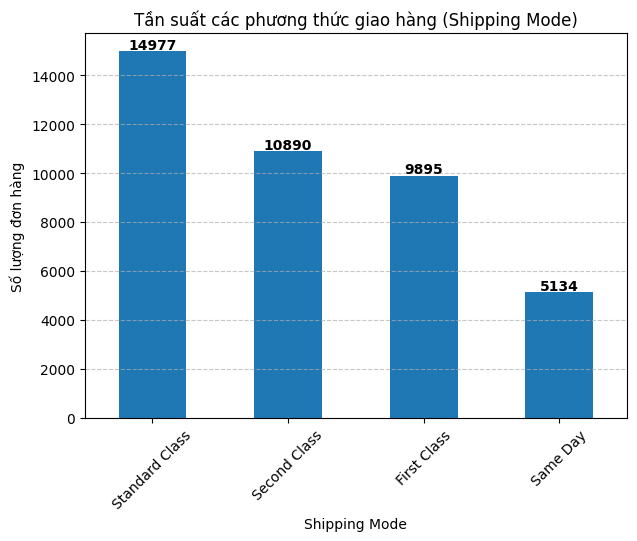

In [ ]:
import matplotlib.pyplot as plt

# Đếm tần suất từng loại Shipping Mode
shipping_counts = df_phancum['Shipping Mode'].value_counts()

# Vẽ biểu đồ cột
plt.figure(figsize=(7,5))
shipping_counts.plot(kind='bar')

# Thêm tiêu đề và nhãn
plt.title('Tần suất các phương thức giao hàng (Shipping Mode)')
plt.xlabel('Shipping Mode')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị số trên cột
for i, v in enumerate(shipping_counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.show()


# Data Transformation


*    Chọn các trường để tiến hành phân cụm: Benefit per order, Sales per customer, Days for shipment (scheduled)  --> dùng StandScaler





*   One hot Encoding cho Shipping Mode


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Copy dữ liệu gốc
df = df_agg.copy().reset_index(drop=True)

# --- 1. Chuẩn hóa numeric: Benefit per order, Sales per customer, Days for shipment (scheduled) ---
numeric_cols = ['Benefit per order', 'Sales per customer', 'Days for shipment (scheduled)']
scaler = StandardScaler()

scaled_numeric = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

# --- 2. OneHotEncoding cho Shipping Mode ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
shipping_encoded = ohe.fit_transform(df[['Shipping Mode']])
shipping_cols = ohe.get_feature_names_out(['Shipping Mode'])
shipping_df = pd.DataFrame(shipping_encoded, columns=shipping_cols, index=df.index)

# --- 3. Gộp tất cả lại ---
df_scaled = pd.concat([scaled_numeric, shipping_df], axis=1)

# --- 4. Kiểm tra kết quả ---
df_scaled


,Benefit per order,Sales per customer,Days for shipment (scheduled),Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,-0.351844,-0.577416,-0.844943,1.0,0.0,0.0,0.0
1,-0.340543,-0.555824,-0.163214,0.0,0.0,1.0,0.0
2,-0.308334,-0.559297,1.200243,0.0,0.0,0.0,1.0
3,-0.340091,-0.580502,-0.844943,1.0,0.0,0.0,0.0
4,0.028141,-0.014897,-0.844943,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
40891,-0.359642,-0.615281,1.200243,0.0,0.0,0.0,1.0
40892,-0.328526,-0.596707,-1.526672,0.0,1.0,0.0,0.0
40893,0.399913,0.713621,-0.844943,1.0,0.0,0.0,0.0
40894,-1.801678,1.867750,-0.163214,0.0,0.0,1.0,0.0


# Clustering

In [ ]:
pip install kneed

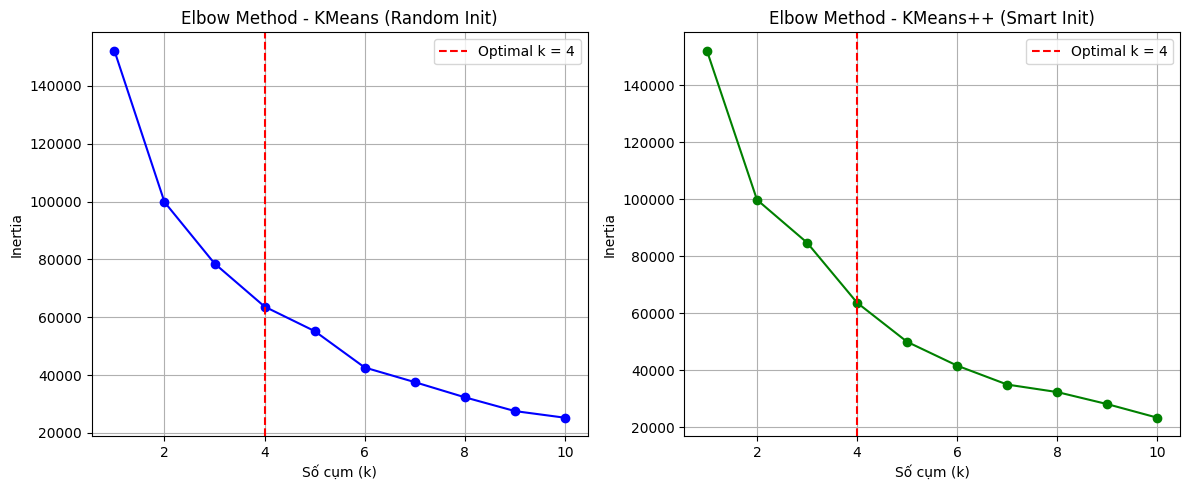

🔹 KMeans (Random): số cụm tối ưu = 4
🔹 KMeans++ (k-means++): số cụm tối ưu = 4


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator
import numpy as np

# --- Chuẩn bị dữ liệu ---
X = df_scaled.copy()

# --- Phạm vi số cụm ---
k_range = range(1, 11)
inertia_kmeans = []
inertia_kmeanspp = []

# --- Chạy KMeans thường và KMeans++ ---
for k in k_range:
    # KMeans random (init='random')
    kmeans = KMeans(n_clusters=k, init='random', random_state=42)
    kmeans.fit(X)
    inertia_kmeans.append(kmeans.inertia_)

    # KMeans++ (init='k-means++')
    kmeanspp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeanspp.fit(X)
    inertia_kmeanspp.append(kmeanspp.inertia_)

# --- Dùng KneeLocator tìm điểm gấp (số cụm tối ưu) ---
knee_kmeans = KneeLocator(k_range, inertia_kmeans, curve='convex', direction='decreasing')
knee_kmeanspp = KneeLocator(k_range, inertia_kmeanspp, curve='convex', direction='decreasing')

# --- Vẽ 2 biểu đồ song song ---
plt.figure(figsize=(12, 5))

# --- Biểu đồ 1: KMeans thường ---
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_kmeans, 'o-', color='blue')
plt.axvline(x=knee_kmeans.knee, color='red', linestyle='--', label=f'Optimal k = {knee_kmeans.knee}')
plt.title('Elbow Method - KMeans (Random Init)')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)

# --- Biểu đồ 2: KMeans++ ---
plt.subplot(1, 2, 2)
plt.plot(k_range, inertia_kmeanspp, 'o-', color='green')
plt.axvline(x=knee_kmeanspp.knee, color='red', linestyle='--', label=f'Optimal k = {knee_kmeanspp.knee}')
plt.title('Elbow Method - KMeans++ (Smart Init)')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- In kết quả ---
print(f"🔹 KMeans (Random): số cụm tối ưu = {knee_kmeans.knee}")
print(f"🔹 KMeans++ (k-means++): số cụm tối ưu = {knee_kmeanspp.knee}")

Số cụm tối ưu k=4 ở cả 2 phương pháp Kmeans và Kmeans ++

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Danh sách số cụm muốn thử
k_values = [ 4]

# Khởi tạo list để lưu kết quả
results = []

for k in k_values:
    # KMeans init = 'random'
    kmeans_random = KMeans(n_clusters=k, init='random', random_state=42)
    labels_random = kmeans_random.fit_predict(df_scaled)
    sil_random = silhouette_score(df_scaled, labels_random)

    # KMeans init = 'k-means++'
    kmeans_pp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels_pp = kmeans_pp.fit_predict(df_scaled)
    sil_pp = silhouette_score(df_scaled, labels_pp)

    # Lưu kết quả
    results.append({
        'K': k,
        'Init Method': 'random',
        'Silhouette Score': sil_random
    })
    results.append({
        'K': k,
        'Init Method': 'k-means++',
        'Silhouette Score': sil_pp
    })

# Chuyển sang DataFrame
df_results = pd.DataFrame(results)

# Hiển thị kết quả
print(df_results)

   K Init Method  Silhouette Score
0  4      random          0.473152
1  4   k-means++          0.472954


Giá trị Silhouette của Kmeans lớn hơn Kmeans++ --> phân cụm theo Kmeans

Thực hiện phân cụm với k=4 theo phương pháp Kmeans

In [ ]:
from sklearn.cluster import KMeans

# --- 1. Khởi tạo KMeans++ với k=4 ---
kmeans = KMeans(n_clusters=4, init='random', random_state=42)

# --- 2. Fit và gán nhãn trên df_scaled (chỉ các cột đã chuẩn hóa) ---
cluster_labels = kmeans.fit_predict(df_scaled)

# --- 3. Thêm nhãn cluster vào df_scaled ---
df_scaled['Cluster'] = cluster_labels

# --- 4. Thêm nhãn cluster vào df_phancum bằng cách merge theo index ---
df_phancum = df_phancum.reset_index(drop=True)
df_scaled_merge = df_scaled.reset_index(drop=True)

# Gán cột Cluster từ df_scaled sang df_phancum
df_phancum['Cluster'] = df_scaled_merge['Cluster']

# Kiểm tra kết quả
df_phancum


,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment,Cluster
0,2015-01-01,Accessories,First Class,1.0,3.600000,59.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer],2
1,2015-01-01,Accessories,Second Class,2.0,6.600000,87.959999,[35.1572609],[-89.78952789],[Mexico City],[Corporate],0
2,2015-01-01,Accessories,Standard Class,4.0,15.150000,83.459999,"[29.52001, 40.76358032]","[-98.63741303, -73.83003998]","[Dos Quebradas, Santo Domingo]","[Home Office, Consumer]",1
3,2015-01-01,Baseball & Softball,First Class,1.0,6.720000,55.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer],2
4,2015-01-01,Camping & Hiking,First Class,1.0,104.469994,788.950028,"[36.05979919, 18.27436447, 33.97929382]","[-86.67125702, -66.37054443, -118.289093]","[Madero, San Juan del Río, Tegucigalpa]","[Consumer, Consumer, Consumer]",2
...,...,...,...,...,...,...,...,...,...,...,...
40891,2018-01-31,Toys,Standard Class,4.0,1.530000,10.910000,[41.83079147],[-87.80297852],[Bekasi],[Corporate],1
40892,2018-01-31,Video Games,Same Day,0.0,9.790000,34.980000,[25.86028481],[-80.19734192],[Gold Coast],[Corporate],2
40893,2018-01-31,Women's Clothing,First Class,1.0,203.160000,1733.040009,"[18.21002388, 40.67771912, 43.60348129, 33.521...","[-66.0370636, -73.96311951, -84.78716278, -82....","[Singapur, Orange, Aurangabad, Bekasi, Delhi, ...","[Home Office, Consumer, Corporate, Consumer, H...",2
40894,2018-01-31,Women's Clothing,Second Class,2.0,-381.270005,3228.680008,"[18.23366928, 18.23006058, 40.41231918, 38.687...","[-66.0370636, -66.03705597, -104.6923523, -77....","[Srinagar, Pekín, Tasikmalaya, Srinagar, Jodhp...","[Consumer, Consumer, Consumer, Corporate, Cons...",0


In [ ]:
df_cluster0 = df_phancum[df_phancum['Cluster'] == 0].reset_index(drop=True)
df_cluster1 = df_phancum[df_phancum['Cluster'] == 1].reset_index(drop=True)
df_cluster2 = df_phancum[df_phancum['Cluster'] == 2].reset_index(drop=True)
df_cluster3 = df_phancum[df_phancum['Cluster'] == 3].reset_index(drop=True)

print("Số dòng thuộc mỗi cụm:")
print("Cluster 0:", df_cluster0.shape)
print("Cluster 1:", df_cluster1.shape)
print("Cluster 2:", df_cluster2.shape)
print("Cluster 3:", df_cluster3.shape)

Số dòng thuộc mỗi cụm:
Cluster 0: (10690, 11)
Cluster 1: (11863, 11)
Cluster 2: (14932, 11)
Cluster 3: (3411, 11)


*   Số lượng trạng thái giao dịch trong cụm 0: 10690

*   Số lượng trạng thái giao dịch trong cụm 1: 11863

*   Số lượng trạng thái giao dịch trong cụm 2: 14932

*   Số lượng trạng thái giao dịch trong cụm 3: 3411







Có sứ chêch lệnh giữa các cụm bởi vì từng cụm là từng phương thức có sự chênh lệch  trong việc dữ liệu đầu vào để phân cụm, nên kết quả phân cụm bị lệch

## Cluster0: Second Class

In [ ]:
df_cluster0

,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment,Cluster
0,2015-01-01,Accessories,Second Class,2.0,6.600000,87.959999,[35.1572609],[-89.78952789],[Mexico City],[Corporate],0
1,2015-01-01,Camping & Hiking,Second Class,2.0,215.969995,799.440018,"[25.88852501, 18.24447441, 37.15639114]","[-80.17294312, -66.37052155, -93.28601074]","[São Paulo, Mexico City, Santiago de Chile]","[Consumer, Consumer, Home Office]",0
2,2015-01-01,Cardio Equipment,Second Class,2.0,48.000000,383.959992,[25.82266045],[-80.28019714],[La Paz],[Consumer],0
3,2015-01-01,Cleats,Second Class,2.0,15.859998,283.750000,"[25.82266045, 25.82266045, 35.1572609]","[-80.28019714, -80.28019714, -89.78952789]","[La Paz, La Paz, Mexico City]","[Consumer, Consumer, Corporate]",0
4,2015-01-01,Fishing,Second Class,2.0,289.479996,1047.940033,"[28.51626968, 18.26247406, 18.24447441]","[-81.30583191, -66.37059784, -66.37052155]","[Hermosillo, Coyoacán, Mexico City]","[Home Office, Consumer, Consumer]",0
...,...,...,...,...,...,...,...,...,...,...,...
10685,2018-01-25,Video Games,Second Class,2.0,124.140001,455.550001,"[18.27292442, 37.34466934, 47.67959595, 33.665...","[-66.03705597, -122.0356674, -117.4249268, -11...","[Kaiyuan, Bihar Sharif, Hobart, Weifang, Brisb...","[Corporate, Consumer, Consumer, Corporate, Con...",0
10686,2018-01-26,Video Games,Second Class,2.0,0.410000,177.690002,"[18.24472427, 18.21754646, 30.47019768, 34.000...","[-66.03704834, -66.0370636, -84.28425598, -117...","[Sydney, Korba, Visakhapatnam, Sydney, Bendigo]","[Consumer, Consumer, Consumer, Consumer, Home ...",0
10687,2018-01-26,Women's Clothing,Second Class,2.0,231.869994,1175.140015,"[18.27336311, 42.50378037, 36.16954041, 18.214...","[-66.0370636, -90.6690979, -115.1335526, -66.0...","[Bhavnagar, Guwahati, Bhavnagar, Bangkok, Guwa...","[Corporate, Consumer, Consumer, Home Office, C...",0
10688,2018-01-30,Women's Clothing,Second Class,2.0,214.780000,2680.500000,"[18.23246956, 18.21808815, 41.85883331, 42.206...","[-66.03704834, -66.03705597, -87.71582031, -83...","[Bogor, Pune, Daejeon, Rangún, Pasig, Fatehpur...","[Consumer, Home Office, Consumer, Consumer, Co...",0


In [ ]:
df_cluster0['Shipping Mode'].value_counts()


,count
Shipping Mode,
Second Class,10690


In [ ]:
desc_numeric = df_cluster0.describe()
desc_numeric

,Days for shipment (scheduled),Benefit per order,Sales per customer,Cluster
count,10690.0,10690.000000,10690.000000,10690.0
mean,2.0,56.088508,537.752579,0.0
std,0.0,179.154721,487.197064,0.0
min,2.0,-4274.979980,7.990000,0.0
25%,2.0,5.585000,167.982498,0.0
50%,2.0,53.229998,389.980011,0.0
75%,2.0,139.727499,767.935005,0.0
max,2.0,601.130013,5092.260010,0.0


/tmp/ipython-input-1747940618.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster0, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')


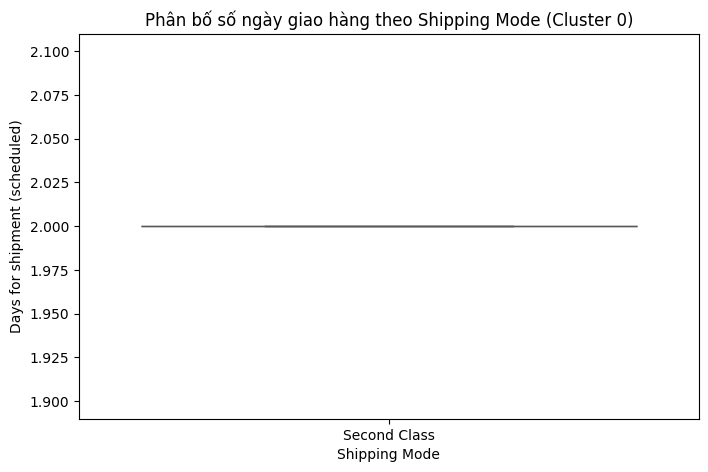

/tmp/ipython-input-1747940618.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_cluster0, x='Shipping Mode', y='Benefit per order', palette='Set3')
/tmp/ipython-input-1747940618.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_cluster0, x='Shipping Mode', y='Sales per customer', palette='Set3')


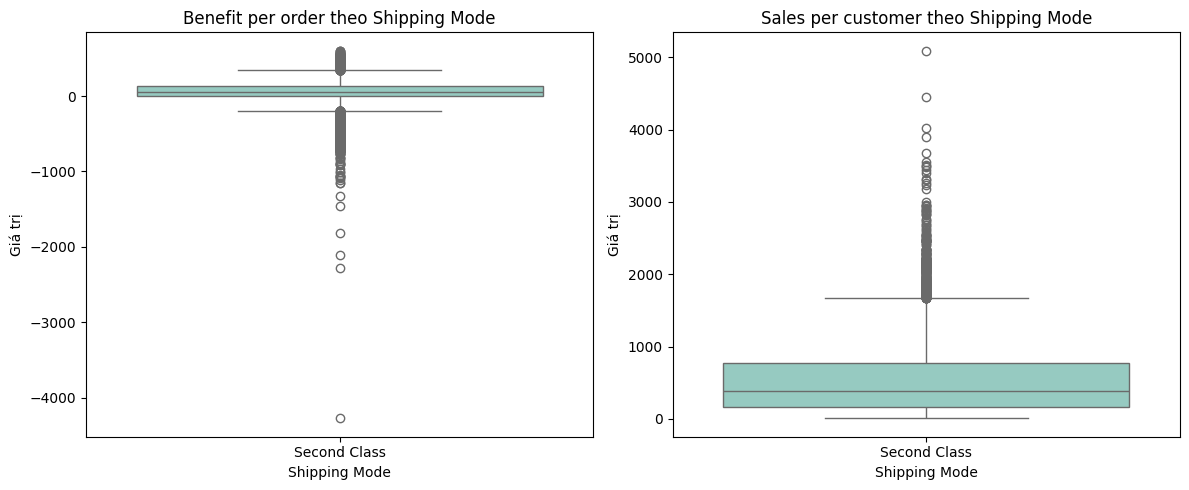

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Lọc dữ liệu cluster 0 ---
df_cluster0 = df_phancum[df_phancum['Cluster'] == 0].copy()

# --- 1️ Phân bố số ngày theo Shipping Mode ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster0, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')
plt.title('Phân bố số ngày giao hàng theo Shipping Mode (Cluster 0)')
plt.ylabel('Days for shipment (scheduled)')
plt.xlabel('Shipping Mode')
plt.show()

# --- 2️ So sánh lợi nhuận và doanh số ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], data=df_cluster0, x='Shipping Mode', y='Benefit per order', palette='Set3')
axes[0].set_title('Benefit per order theo Shipping Mode')

sns.boxplot(ax=axes[1], data=df_cluster0, x='Shipping Mode', y='Sales per customer', palette='Set3')
axes[1].set_title('Sales per customer theo Shipping Mode')

for ax in axes:
    ax.set_xlabel('Shipping Mode')
    ax.set_ylabel('Giá trị')
plt.tight_layout()
plt.show()


Cụm 0 số ngày giao hàng trễ tiêu chuẩn là 0 ngày, nên không có việc giao trễ --> vấn đề giao hàng trễ xảy ra

/tmp/ipython-input-2385320546.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')


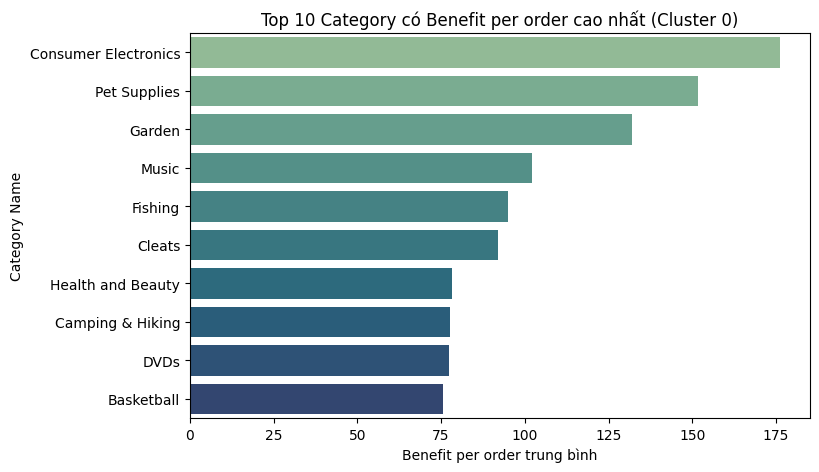

In [ ]:
top10_benefit = (
    df_cluster0.groupby('Category Name')['Benefit per order']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')
plt.title('Top 10 Category có Benefit per order cao nhất (Cluster 0)')
plt.xlabel('Benefit per order trung bình')
plt.ylabel('Category Name')
plt.show()


Consumer Electronics là nhóm có lợi nhuận cao nhất

/tmp/ipython-input-1386819321.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')


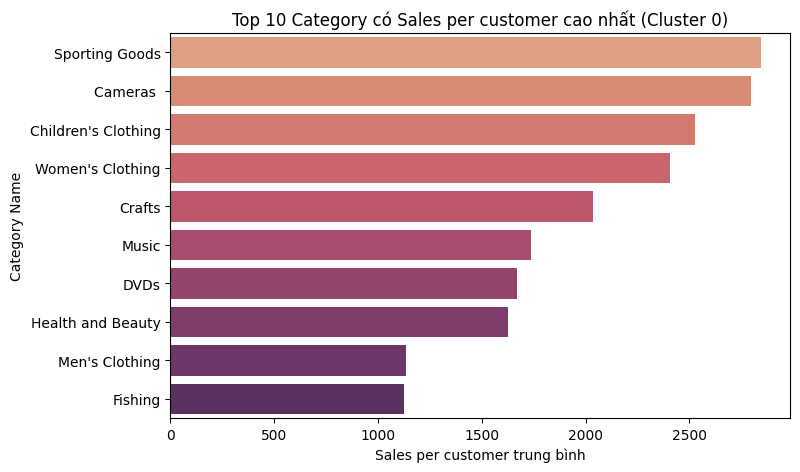

In [ ]:
top10_sales = (
    df_cluster0.groupby('Category Name')['Sales per customer']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')
plt.title('Top 10 Category có Sales per customer cao nhất (Cluster 0)')
plt.xlabel('Sales per customer trung bình')
plt.ylabel('Category Name')
plt.show()


Sporting Goods là nhóm có doanh thu cao nhất

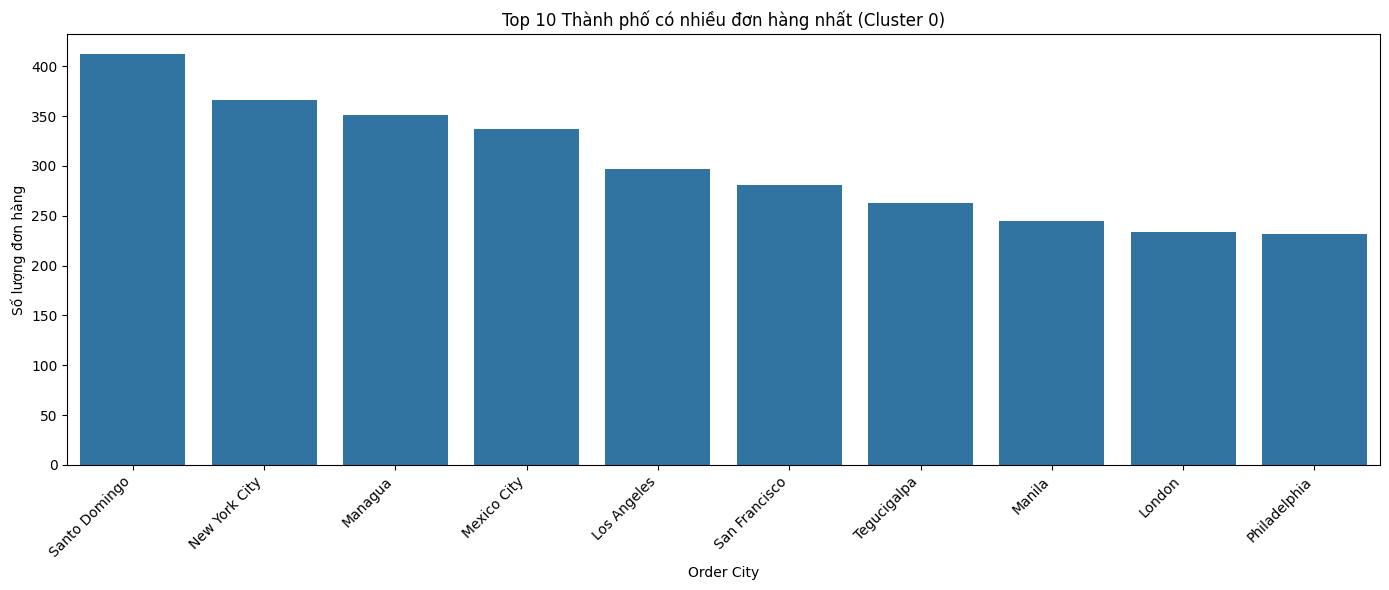

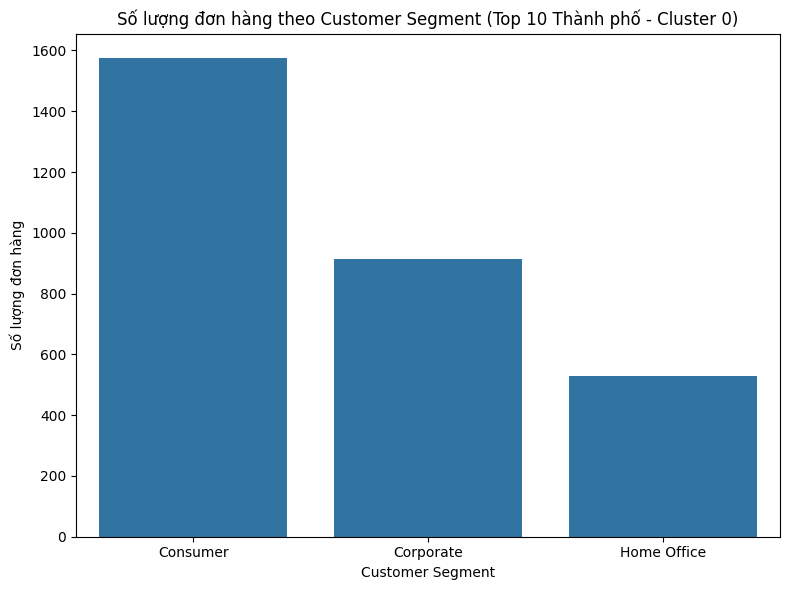

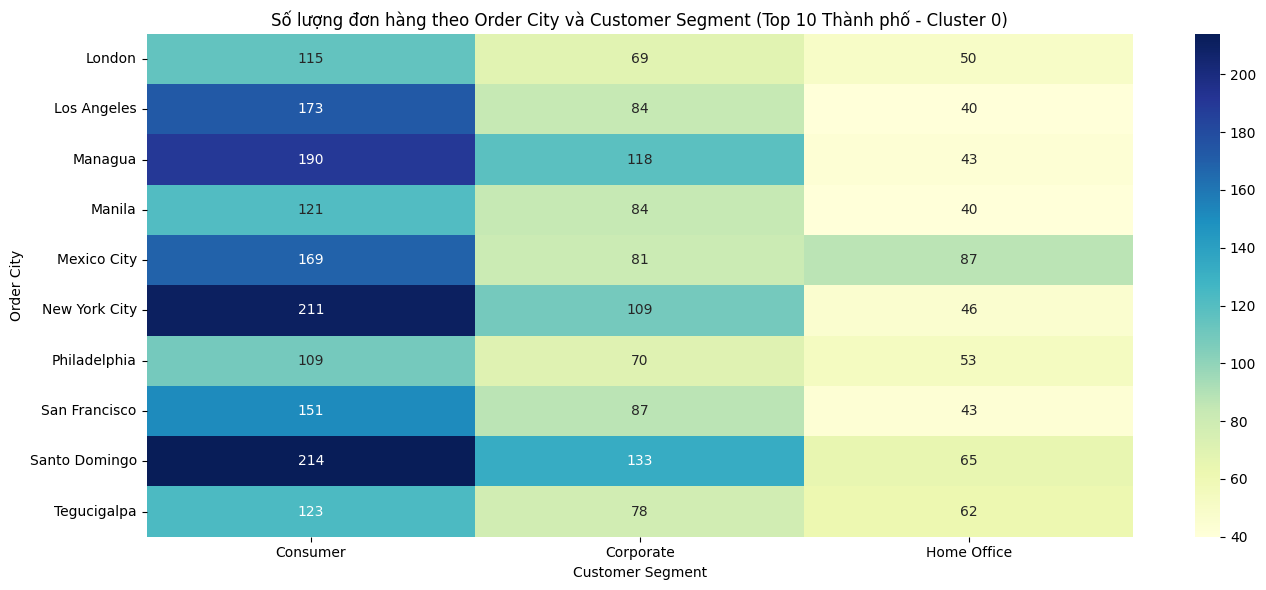

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Giả sử df_cluster0 đã có ---
df = df_cluster0.copy()

# --- Nổ list thành từng dòng riêng cho Order City và Customer Segment ---
df_exploded = df.explode(['Order City', 'Customer Segment'])

# --- Lấy Top 10 thành phố có nhiều đơn hàng nhất ---
top_10_cities = df_exploded['Order City'].value_counts().head(10).index
df_top10 = df_exploded[df_exploded['Order City'].isin(top_10_cities)]

# --- Biểu đồ 1: Số lượng đơn hàng theo Order City (Top 10) ---
plt.figure(figsize=(14,6))
sns.countplot(data=df_top10, x='Order City', order=top_10_cities)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Thành phố có nhiều đơn hàng nhất (Cluster 0)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Order City')
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Số lượng đơn hàng theo Customer Segment ---
plt.figure(figsize=(8,6))
sns.countplot(data=df_top10, x='Customer Segment', order=df_top10['Customer Segment'].value_counts().index)
plt.title('Số lượng đơn hàng theo Customer Segment (Top 10 Thành phố - Cluster 0)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Heatmap kết hợp Order City và Customer Segment (Top 10 Thành phố) ---
city_segment_table = pd.crosstab(df_top10['Order City'], df_top10['Customer Segment'])
plt.figure(figsize=(14,6))
sns.heatmap(city_segment_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Số lượng đơn hàng theo Order City và Customer Segment (Top 10 Thành phố - Cluster 0)')
plt.ylabel('Order City')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()


Santo Domingo là thành phố có nhiều đơn hàng được giao đến nhất

Consumer là phân khúc có nhiều đơn hàng nhất

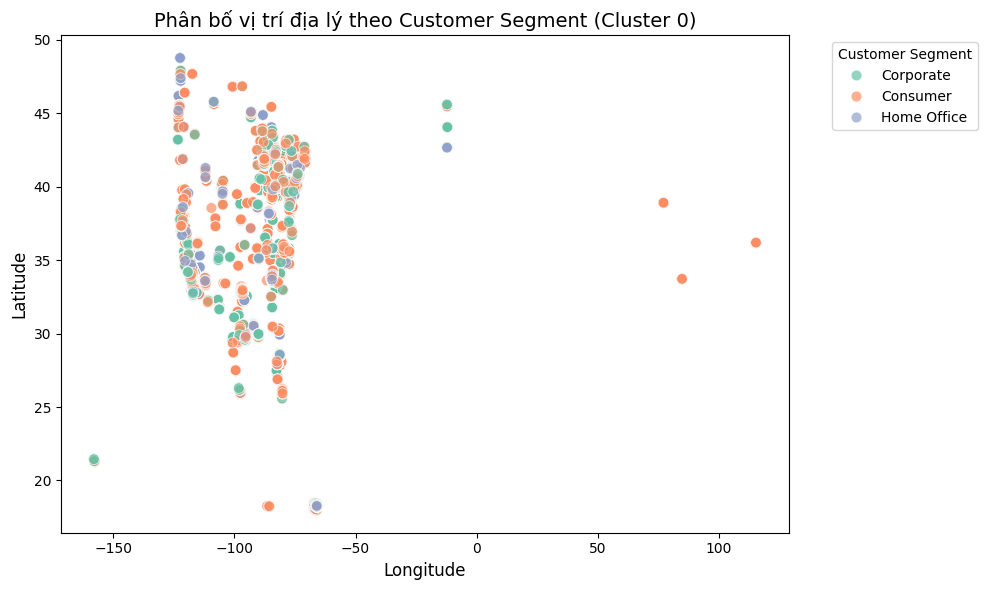

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sao chép cluster 0 ---
df_cluster0 = df_phancum[df_phancum['Cluster'] == 0].copy()

# --- Chuyển từ string list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

df_cluster0['Latitude'] = df_cluster0['Latitude'].apply(safe_eval)
df_cluster0['Longitude'] = df_cluster0['Longitude'].apply(safe_eval)
df_cluster0['Customer Segment'] = df_cluster0['Customer Segment'].apply(safe_eval)

# --- Gộp lại thành list các tuple (lat, long) ---
df_cluster0['Coords'] = df_cluster0.apply(lambda row: list(zip(row['Latitude'], row['Longitude'])), axis=1)

# --- explode cả Coords và Customer Segment ---
df_cluster0 = df_cluster0.explode(['Coords', 'Customer Segment']).reset_index(drop=True)

# --- Tách lại ra 2 cột Latitude/Longitude ---
df_cluster0['Latitude'] = df_cluster0['Coords'].apply(lambda x: x[0])
df_cluster0['Longitude'] = df_cluster0['Coords'].apply(lambda x: x[1])

# --- Xóa cột Coords dư ---
df_cluster0.drop(columns=['Coords'], inplace=True)

# --- Vẽ scatterplot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster0,
    x='Longitude',
    y='Latitude',
    hue='Customer Segment',
    alpha=0.7,
    s=60,
    palette='Set2'
)
plt.title('Phân bố vị trí địa lý theo Customer Segment (Cluster 0)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Vĩ độ địa lí tập trung trải rộng kinh độ từ -130 đến  -70, trải từ kinh độ 25 đến 50. Phân khúc khách hàng ứng với vĩ độ nào cũng đều có

## Cluster 1: Standard Class

In [ ]:
df_cluster1

,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment,Cluster
0,2015-01-01,Accessories,Standard Class,4.0,15.150000,83.459999,"[29.52001, 40.76358032]","[-98.63741303, -73.83003998]","[Dos Quebradas, Santo Domingo]","[Home Office, Consumer]",1
1,2015-01-01,Electronics,Standard Class,4.0,116.689997,380.860008,"[29.38430595, 33.76267624, 35.17372131]","[-100.7502518, -117.8080368, -89.94194031]","[Santo Domingo, Managua, Brasília]","[Consumer, Consumer, Consumer]",1
2,2015-01-01,Golf Balls,Standard Class,4.0,2.400000,59.970001,[34.21546936],[-118.3703384],[San Miguelito],[Corporate],1
3,2015-01-01,Golf Gloves,Standard Class,4.0,8.440000,17.580000,[39.5646553],[-87.28941345],[Tulancingo],[Home Office],1
4,2015-01-01,Hockey,Standard Class,4.0,23.490000,87.000000,[18.21840668],[-66.37054443],[Managua],[Home Office],1
...,...,...,...,...,...,...,...,...,...,...,...
11858,2018-01-24,Video Games,Standard Class,4.0,271.620002,1694.729994,"[42.39173126, 18.24283409, 18.28047752, 18.240...","[-83.10753632, -66.0370636, -66.03705597, -66....","[Gold Coast, Bangkok, Sydney, Bendigo, Zhaoyua...","[Corporate, Home Office, Consumer, Consumer, C...",1
11859,2018-01-25,Video Games,Standard Class,4.0,220.910001,1284.109993,"[30.60759926, 40.86119461, 39.95473099, 18.218...","[-96.31684876, -73.87054443, -75.20536804, -66...","[Ajmer, Melbourne, Manila, Bangkok, Chennai, M...","[Corporate, Corporate, Corporate, Consumer, Co...",1
11860,2018-01-26,Video Games,Standard Class,4.0,119.810000,614.329994,"[18.40143013, 18.22299957, 33.54924011, 26.231...","[-65.97364807, -66.03705597, -84.25650024, -80...","[Dhule, Chaoyang, Chaoyang, Korba, Chaoyang, C...","[Consumer, Consumer, Consumer, Consumer, Consu...",1
11861,2018-01-31,Sporting Goods,Standard Class,4.0,91.250000,314.640015,[18.2514534],[-66.03705597],[Bekasi],[Consumer],1


In [ ]:
df_cluster1['Shipping Mode'].value_counts()


,count
Shipping Mode,
Standard Class,11863


In [ ]:
desc_numeric = df_cluster1.describe()
desc_numeric

,Days for shipment (scheduled),Benefit per order,Sales per customer,Cluster
count,11863.0,11863.000000,11863.000000,11863.0
mean,4.0,42.731884,832.654614,1.0
std,0.0,194.157757,867.996319,0.0
min,4.0,-3119.249949,7.490000,1.0
25%,4.0,1.049997,116.969999,1.0
50%,4.0,36.389999,494.669994,1.0
75%,4.0,137.799999,1388.264992,1.0
max,4.0,462.739998,7237.610199,1.0


/tmp/ipython-input-3141705436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster1, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')


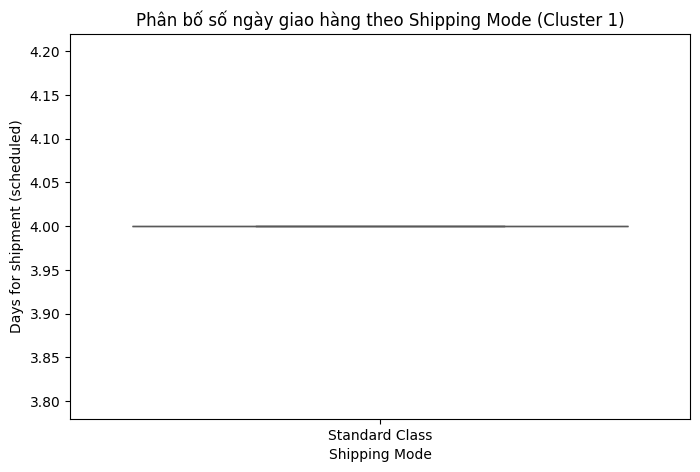

/tmp/ipython-input-3141705436.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_cluster1, x='Shipping Mode', y='Benefit per order', palette='Set3')
/tmp/ipython-input-3141705436.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_cluster1, x='Shipping Mode', y='Sales per customer', palette='Set3')


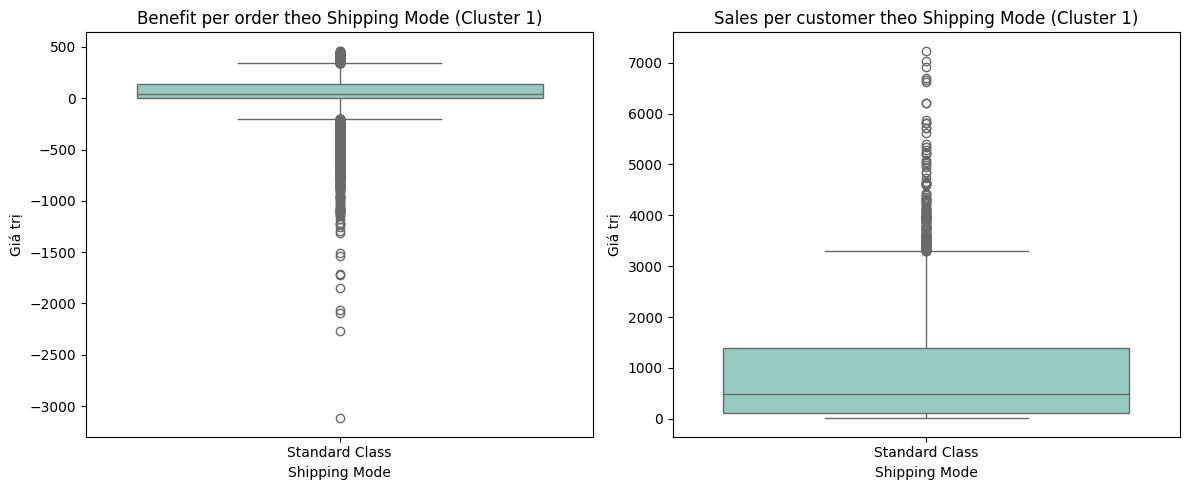

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Lọc dữ liệu cluster 1 ---
df_cluster1 = df_phancum[df_phancum['Cluster'] == 1].copy()

# --- 1️ Phân bố số ngày theo Shipping Mode ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster1, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')
plt.title('Phân bố số ngày giao hàng theo Shipping Mode (Cluster 1)')
plt.ylabel('Days for shipment (scheduled)')
plt.xlabel('Shipping Mode')
plt.show()

# --- 2️ So sánh lợi nhuận và doanh số ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], data=df_cluster1, x='Shipping Mode', y='Benefit per order', palette='Set3')
axes[0].set_title('Benefit per order theo Shipping Mode (Cluster 1)')

sns.boxplot(ax=axes[1], data=df_cluster1, x='Shipping Mode', y='Sales per customer', palette='Set3')
axes[1].set_title('Sales per customer theo Shipping Mode (Cluster 1)')

for ax in axes:
    ax.set_xlabel('Shipping Mode')
    ax.set_ylabel('Giá trị')

plt.tight_layout()
plt.show()


Số ngày giao hàng đều là 4

/tmp/ipython-input-748860146.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')


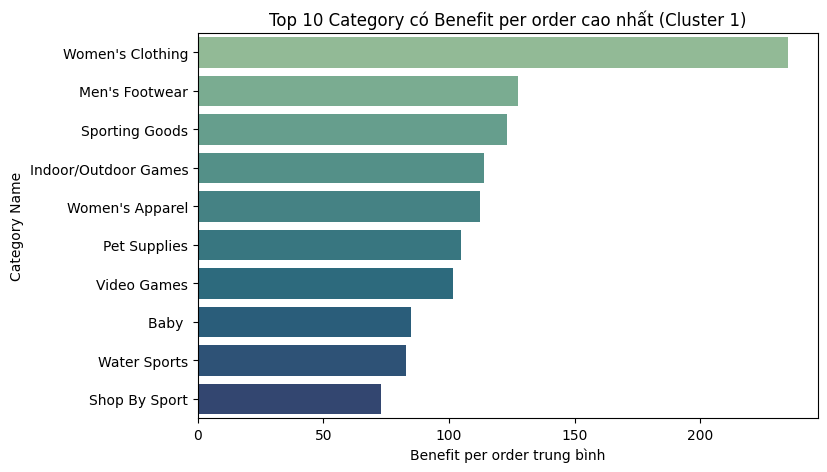

In [ ]:
top10_benefit = (
    df_cluster1.groupby('Category Name')['Benefit per order']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')
plt.title('Top 10 Category có Benefit per order cao nhất (Cluster 1)')
plt.xlabel('Benefit per order trung bình')
plt.ylabel('Category Name')
plt.show()


Women's Clothing là nhóm Category có lợi nhuận cao nhất

/tmp/ipython-input-1428077144.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')


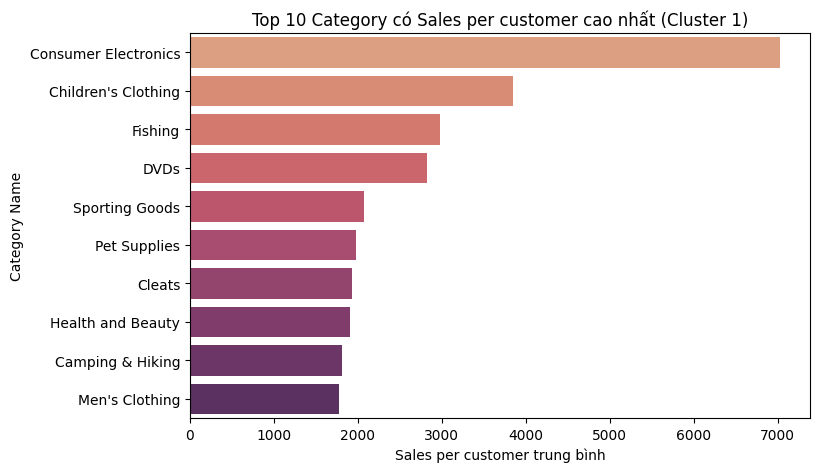

In [ ]:
top10_sales = (
    df_cluster1.groupby('Category Name')['Sales per customer']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')
plt.title('Top 10 Category có Sales per customer cao nhất (Cluster 1)')
plt.xlabel('Sales per customer trung bình')
plt.ylabel('Category Name')
plt.show()

Consumer Electronics là nhóm có doanh thu cao nhất

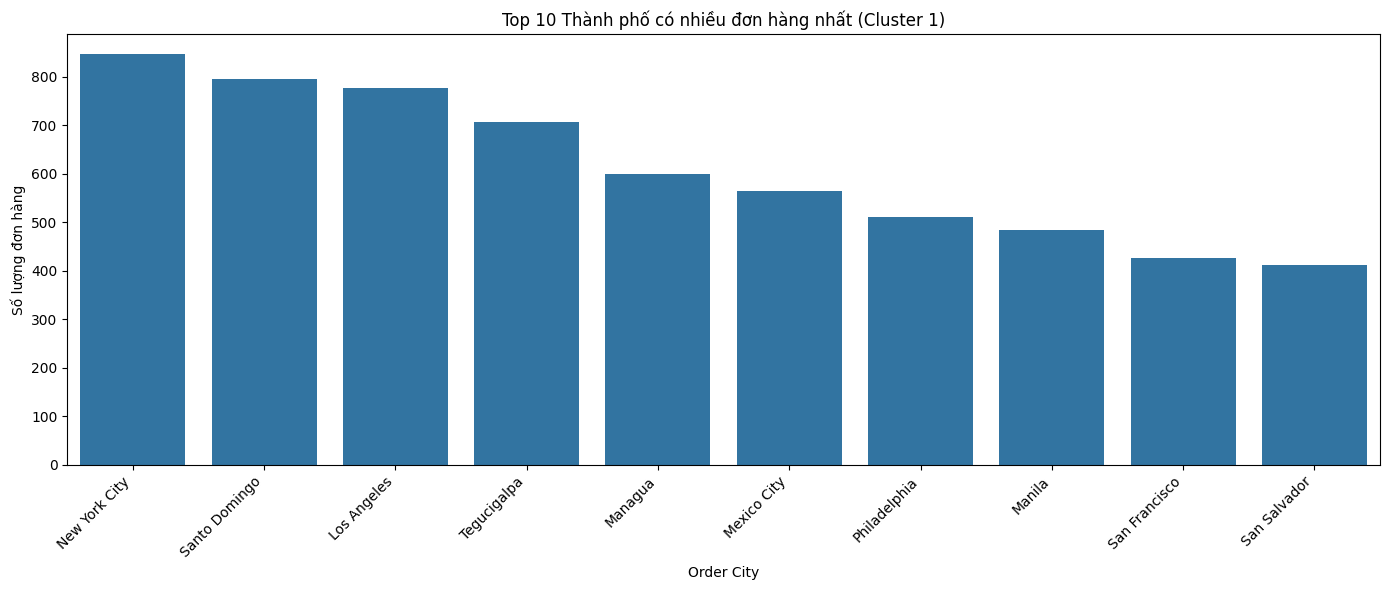

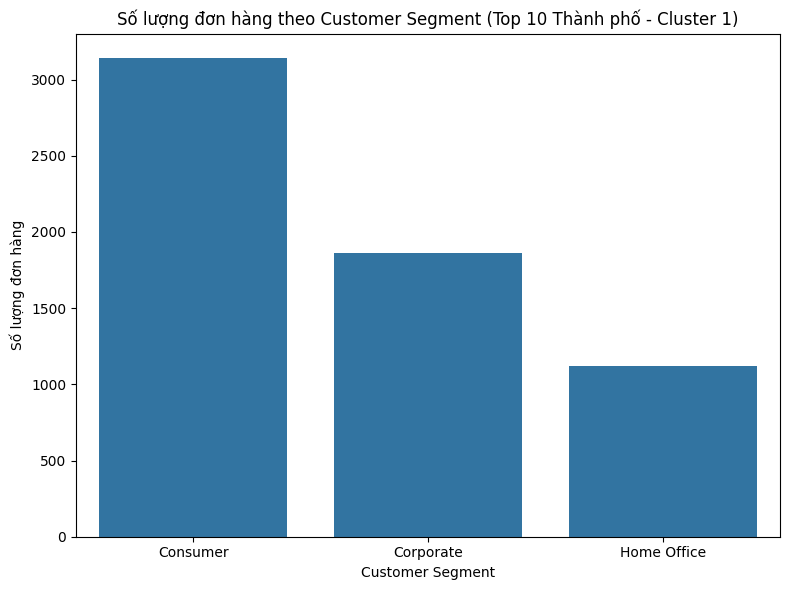

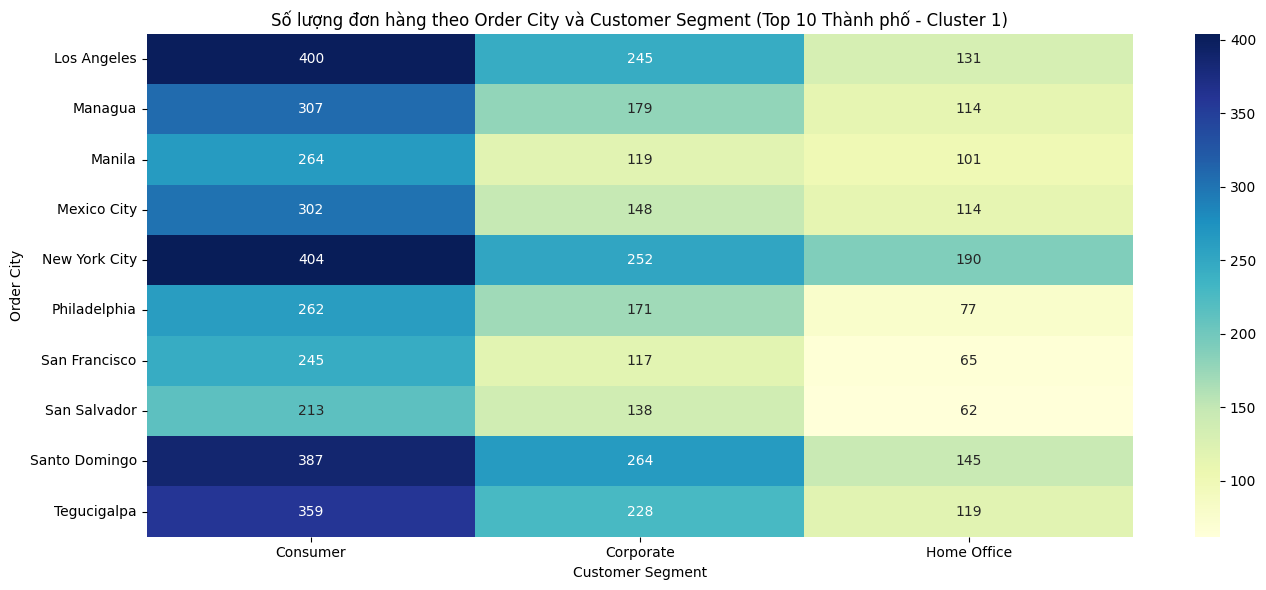

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Lọc Cluster 1 ---
df_cluster1 = df_phancum[df_phancum['Cluster'] == 1].copy()

# --- Nổ list thành từng dòng riêng cho Order City và Customer Segment ---
df_exploded = df_cluster1.explode(['Order City', 'Customer Segment'])

# --- Lấy Top 10 thành phố có nhiều đơn hàng nhất ---
top_10_cities = df_exploded['Order City'].value_counts().head(10).index
df_top10 = df_exploded[df_exploded['Order City'].isin(top_10_cities)]

# --- Biểu đồ 1: Số lượng đơn hàng theo Order City (Top 10) ---
plt.figure(figsize=(14,6))
sns.countplot(data=df_top10, x='Order City', order=top_10_cities)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Thành phố có nhiều đơn hàng nhất (Cluster 1)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Order City')
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Số lượng đơn hàng theo Customer Segment ---
plt.figure(figsize=(8,6))
sns.countplot(data=df_top10, x='Customer Segment', order=df_top10['Customer Segment'].value_counts().index)
plt.title('Số lượng đơn hàng theo Customer Segment (Top 10 Thành phố - Cluster 1)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Heatmap kết hợp Order City và Customer Segment ---
city_segment_table = pd.crosstab(df_top10['Order City'], df_top10['Customer Segment'])
plt.figure(figsize=(14,6))
sns.heatmap(city_segment_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Số lượng đơn hàng theo Order City và Customer Segment (Top 10 Thành phố - Cluster 1)')
plt.ylabel('Order City')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()


New York City là nơi có số lượng đơn hàng đến cao nhất, Consumer vẫn là phân khúc khách hàng đông nhất

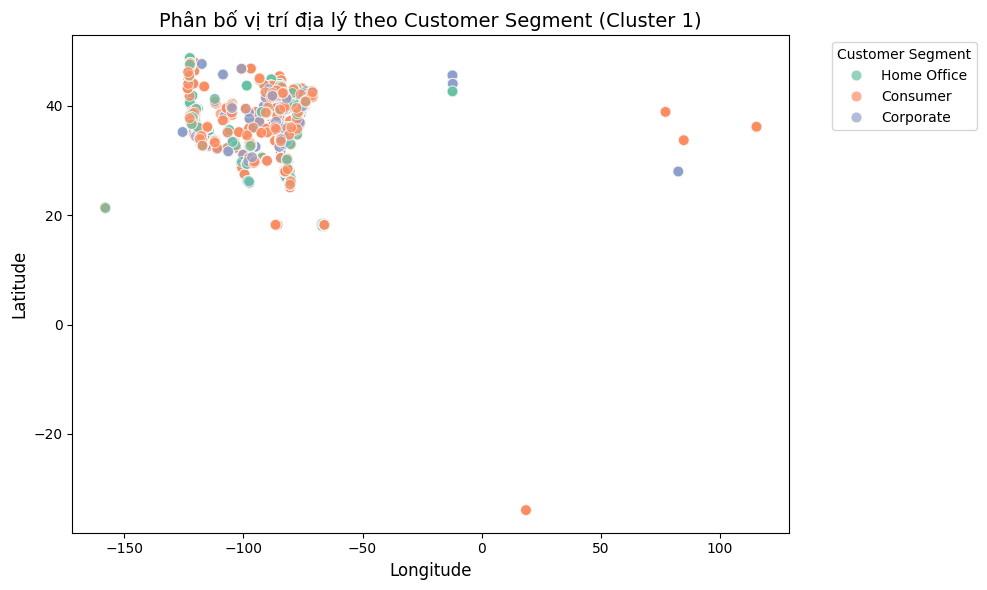

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sao chép cluster 1 ---
df_cluster1 = df_phancum[df_phancum['Cluster'] == 1].copy()

# --- Chuyển từ string list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

df_cluster1['Latitude'] = df_cluster1['Latitude'].apply(safe_eval)
df_cluster1['Longitude'] = df_cluster1['Longitude'].apply(safe_eval)
df_cluster1['Customer Segment'] = df_cluster1['Customer Segment'].apply(safe_eval)

# --- Gộp lại thành list các tuple (lat, long) ---
df_cluster1['Coords'] = df_cluster1.apply(lambda row: list(zip(row['Latitude'], row['Longitude'])), axis=1)

# --- Explode cả Coords và Customer Segment ---
df_cluster1 = df_cluster1.explode(['Coords', 'Customer Segment']).reset_index(drop=True)

# --- Tách lại ra 2 cột Latitude/Longitude ---
df_cluster1['Latitude'] = df_cluster1['Coords'].apply(lambda x: x[0])
df_cluster1['Longitude'] = df_cluster1['Coords'].apply(lambda x: x[1])

# --- Xóa cột Coords dư ---
df_cluster1.drop(columns=['Coords'], inplace=True)

# --- Vẽ scatterplot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster1,
    x='Longitude',
    y='Latitude',
    hue='Customer Segment',
    alpha=0.7,
    s=60,
    palette='Set2'
)
plt.title('Phân bố vị trí địa lý theo Customer Segment (Cluster 1)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Tọa độ vị trí địa lí theo kinh độ tập trung 1 tọa độ -130 --> -70,  vĩ độ tập trung 1 khu vực 25 đến 45, Cluster 1 thể hiện rõ đặc tính của cụm

## Cluster2:First Class 9804,Same Day 5128 --> First Class chiếm đa số

In [ ]:
df_cluster2

,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment,Cluster
0,2015-01-01,Accessories,First Class,1.0,3.600000,59.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer],2
1,2015-01-01,Baseball & Softball,First Class,1.0,6.720000,55.980000,[40.86585236],[-73.87036896],[San Cristóbal de Las Casas],[Consumer],2
2,2015-01-01,Camping & Hiking,First Class,1.0,104.469994,788.950028,"[36.05979919, 18.27436447, 33.97929382]","[-86.67125702, -66.37054443, -118.289093]","[Madero, San Juan del Río, Tegucigalpa]","[Consumer, Consumer, Consumer]",2
3,2015-01-01,Cardio Equipment,First Class,1.0,53.119999,273.969994,"[18.27436447, 42.03330612]","[-66.37054443, -88.29245758]","[San Juan del Río, Madero]","[Consumer, Home Office]",2
4,2015-01-01,Cleats,First Class,1.0,52.869999,301.750008,"[42.10362625, 42.03330612]","[-76.03582764, -88.29245758]","[Milpa Alta, Madero]","[Consumer, Home Office]",2
...,...,...,...,...,...,...,...,...,...,...,...
14927,2018-01-29,Women's Clothing,Same Day,0.0,24.549999,196.399994,[38.77690125],[-104.8097305],[Kowloon],[Home Office],2
14928,2018-01-30,Women's Clothing,First Class,1.0,336.309998,1892.740006,"[18.27737618, 38.56019592, 38.48671341, 37.325...","[-66.03705597, -90.28090668, -121.459343, -121...","[Medan, Pasig, Amritsar, Pasig, Melbourne, Xi'...","[Home Office, Consumer, Corporate, Consumer, C...",2
14929,2018-01-30,Women's Clothing,Same Day,0.0,119.779997,377.690002,"[18.27217484, 34.04991913]","[-66.03705597, -117.7161026]","[Wollongong, Foshan]","[Home Office, Consumer]",2
14930,2018-01-31,Video Games,Same Day,0.0,9.790000,34.980000,[25.86028481],[-80.19734192],[Gold Coast],[Corporate],2


In [ ]:
df_cluster2['Shipping Mode'].value_counts()


,count
Shipping Mode,
First Class,9804
Same Day,5128


In [ ]:
desc_numeric = df_cluster2.describe()
desc_numeric

,Days for shipment (scheduled),Benefit per order,Sales per customer,Cluster
count,14932.000000,14932.000000,14932.000000,14932.0
mean,0.656576,51.042590,432.350302,2.0
std,0.474867,154.532871,410.110986,0.0
min,0.000000,-1585.399906,7.490000,2.0
25%,0.000000,7.000000,149.940002,2.0
50%,1.000000,48.000000,310.440002,2.0
75%,1.000000,117.504999,576.269994,2.0
max,1.000000,720.299988,4215.000000,2.0


/tmp/ipython-input-697102235.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster2, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')


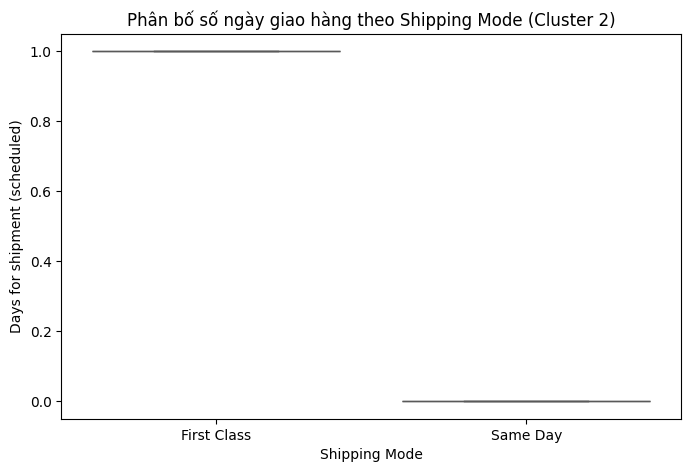

/tmp/ipython-input-697102235.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_cluster2, x='Shipping Mode', y='Benefit per order', palette='Set3')
/tmp/ipython-input-697102235.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_cluster2, x='Shipping Mode', y='Sales per customer', palette='Set3')


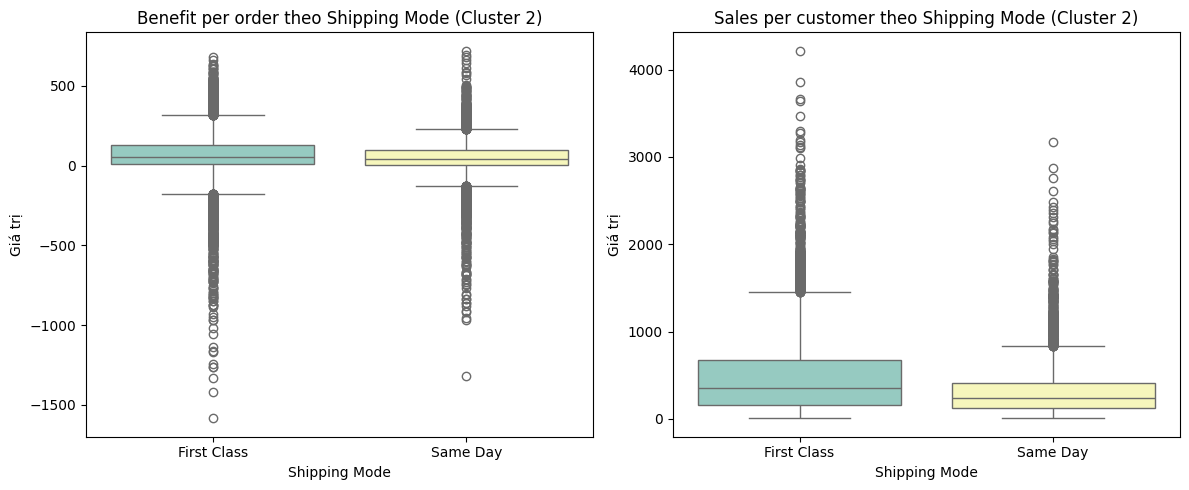

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Lọc dữ liệu cluster 2 ---
df_cluster2 = df_phancum[df_phancum['Cluster'] == 2].copy()

# --- 1️ Phân bố số ngày theo Shipping Mode ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster2, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')
plt.title('Phân bố số ngày giao hàng theo Shipping Mode (Cluster 2)')
plt.ylabel('Days for shipment (scheduled)')
plt.xlabel('Shipping Mode')
plt.show()

# --- 2️ So sánh lợi nhuận và doanh số ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], data=df_cluster2, x='Shipping Mode', y='Benefit per order', palette='Set3')
axes[0].set_title('Benefit per order theo Shipping Mode (Cluster 2)')

sns.boxplot(ax=axes[1], data=df_cluster2, x='Shipping Mode', y='Sales per customer', palette='Set3')
axes[1].set_title('Sales per customer theo Shipping Mode (Cluster 2)')

for ax in axes:
    ax.set_xlabel('Shipping Mode')
    ax.set_ylabel('Giá trị')

plt.tight_layout()
plt.show()

First Class, số ngày giao hàng trễ là 1, Same Day: số ngày giao hàng trễ là 0

/tmp/ipython-input-512153926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')


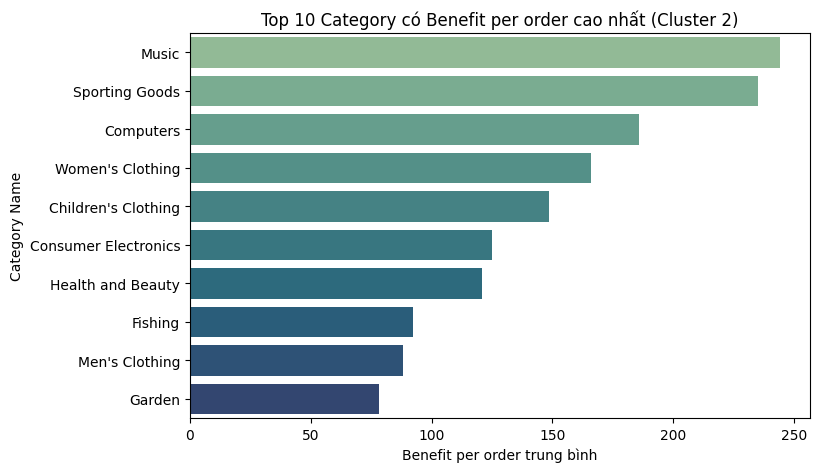

In [ ]:
top10_benefit = (
    df_cluster2.groupby('Category Name')['Benefit per order']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')
plt.title('Top 10 Category có Benefit per order cao nhất (Cluster 2)')
plt.xlabel('Benefit per order trung bình')
plt.ylabel('Category Name')
plt.show()

Music là nhóm có Benefit cao nhất

/tmp/ipython-input-4258172760.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')


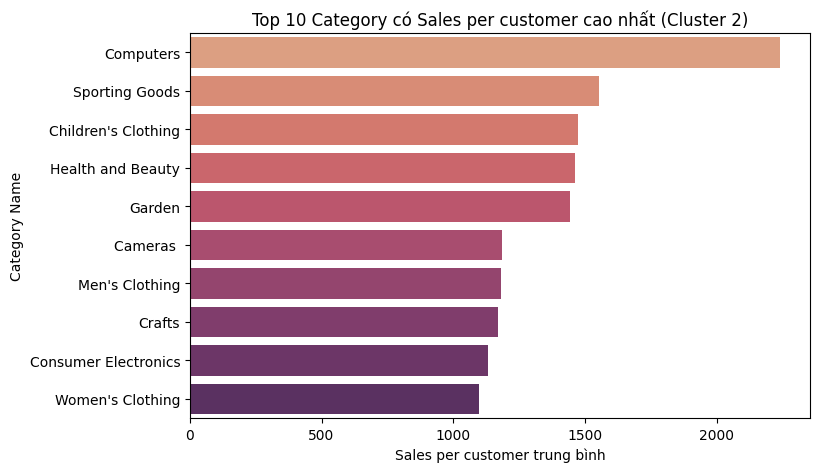

In [ ]:
top10_sales = (
    df_cluster2.groupby('Category Name')['Sales per customer']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_sales.values, y=top10_sales.index, palette='flare')
plt.title('Top 10 Category có Sales per customer cao nhất (Cluster 2)')
plt.xlabel('Sales per customer trung bình')
plt.ylabel('Category Name')
plt.show()

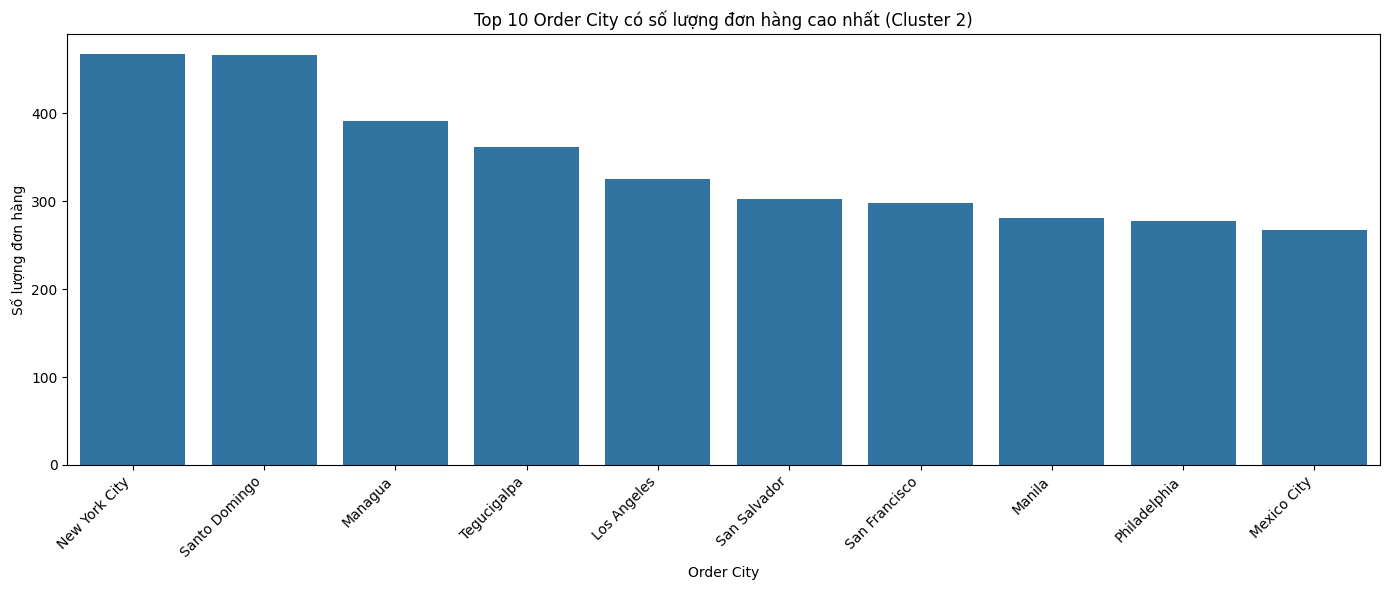

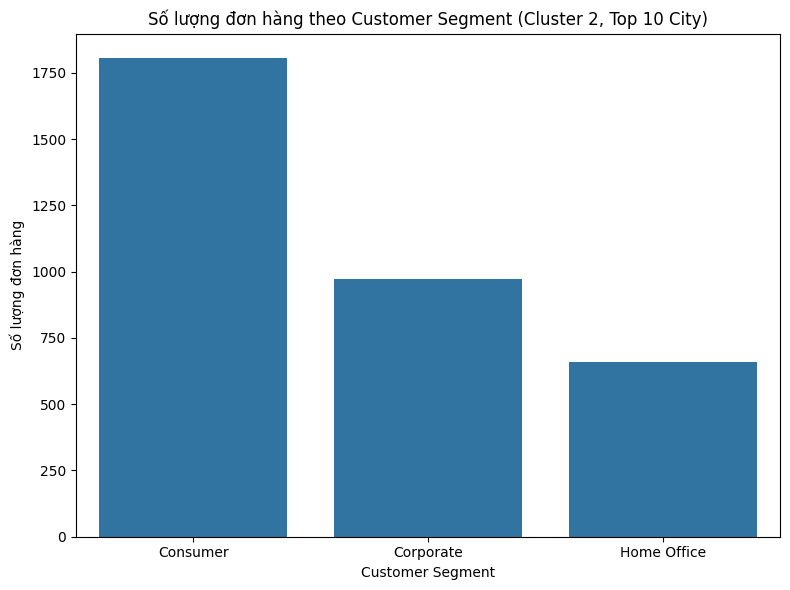

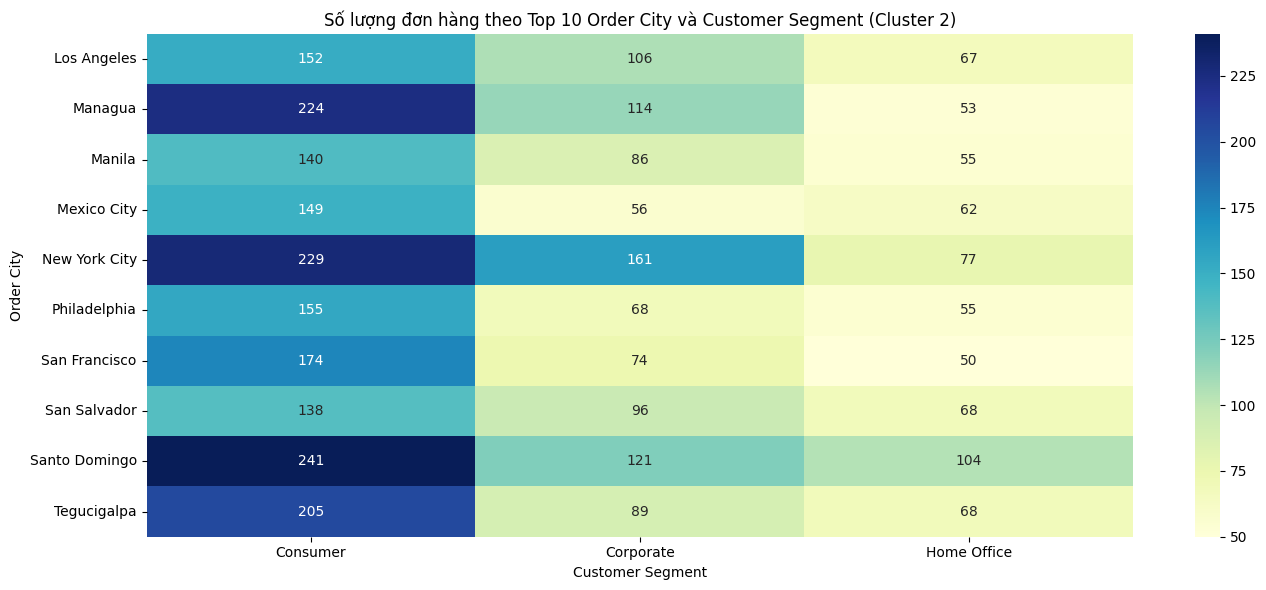

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Lọc Cluster 2 ---
df_cluster2 = df_phancum[df_phancum['Cluster'] == 2].copy()

# --- Nổ list thành từng dòng riêng cho Order City và Customer Segment ---
df_exploded = df_cluster2.explode(['Order City', 'Customer Segment'])

# --- Lấy Top 10 Order City có nhiều đơn hàng nhất ---
top10_cities = df_exploded['Order City'].value_counts().nlargest(10).index
df_top10 = df_exploded[df_exploded['Order City'].isin(top10_cities)]

# --- Biểu đồ 1: Số lượng đơn hàng theo Top 10 Order City ---
plt.figure(figsize=(14,6))
sns.countplot(data=df_top10, x='Order City', order=top10_cities)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Order City có số lượng đơn hàng cao nhất (Cluster 2)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Order City')
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Số lượng đơn hàng theo Customer Segment ---
plt.figure(figsize=(8,6))
sns.countplot(data=df_top10, x='Customer Segment', order=df_top10['Customer Segment'].value_counts().index)
plt.title('Số lượng đơn hàng theo Customer Segment (Cluster 2, Top 10 City)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Heatmap kết hợp Top 10 Order City và Customer Segment ---
city_segment_table = pd.crosstab(df_top10['Order City'], df_top10['Customer Segment'])
plt.figure(figsize=(14,6))
sns.heatmap(city_segment_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Số lượng đơn hàng theo Top 10 Order City và Customer Segment (Cluster 2)')
plt.ylabel('Order City')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()


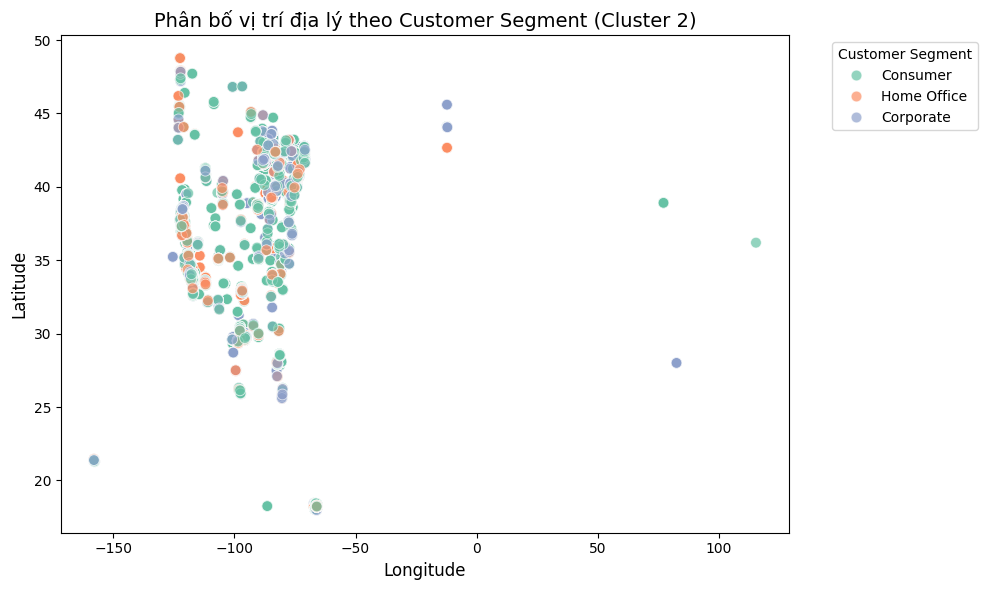

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sao chép cluster 2 ---
df_cluster2 = df_phancum[df_phancum['Cluster'] == 2].copy()

# --- Chuyển từ string list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

df_cluster2['Latitude'] = df_cluster2['Latitude'].apply(safe_eval)
df_cluster2['Longitude'] = df_cluster2['Longitude'].apply(safe_eval)
df_cluster2['Customer Segment'] = df_cluster2['Customer Segment'].apply(safe_eval)

# --- Gộp lại thành list các tuple (lat, long) ---
df_cluster2['Coords'] = df_cluster2.apply(lambda row: list(zip(row['Latitude'], row['Longitude'])), axis=1)

# --- Explode cả Coords và Customer Segment ---
df_cluster2 = df_cluster2.explode(['Coords', 'Customer Segment']).reset_index(drop=True)

# --- Tách lại ra 2 cột Latitude/Longitude ---
df_cluster2['Latitude'] = df_cluster2['Coords'].apply(lambda x: x[0])
df_cluster2['Longitude'] = df_cluster2['Coords'].apply(lambda x: x[1])

# --- Xóa cột Coords dư ---
df_cluster2.drop(columns=['Coords'], inplace=True)

# --- Vẽ scatterplot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster2,
    x='Longitude',
    y='Latitude',
    hue='Customer Segment',
    alpha=0.7,
    s=60,
    palette='Set2'
)
plt.title('Phân bố vị trí địa lý theo Customer Segment (Cluster 2)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Longtitude trải dài trên kinh độ -130 đến -70,; vĩ độ 25 đến 50 tập trung đông nhất, phân khúc khách hàng trải dài trên mọi tọa độ trên

## Cluster3: First Class 91; Same Day 6; Second Class 200; Standard Class 3114 --> Standard Class chiếm đa số

In [ ]:
df_cluster3

,Day,Category Name,Shipping Mode,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order City,Customer Segment,Cluster
0,2015-01-01,Camping & Hiking,Standard Class,4.0,1253.219986,3749.720062,"[18.21652794, 18.26521111, 18.23423767, 18.234...","[-66.3706131, -66.37055206, -66.37060547, -66....","[Lençóis Paulista, Santo Domingo, Dos Quebrada...","[Corporate, Consumer, Consumer, Consumer, Cons...",3
1,2015-01-01,Cardio Equipment,Standard Class,4.0,608.620007,2012.790001,"[34.0863266, 34.0863266, 41.48466873, 18.24758...","[-117.9595337, -117.9595337, -81.77624512, -66...","[Tegucigalpa, Tegucigalpa, São Paulo, São Paul...","[Corporate, Corporate, Consumer, Corporate, Ho...",3
2,2015-01-01,Cleats,Standard Class,4.0,590.189990,2997.690056,"[33.74279404, 34.21546936, 37.1289444, 25.8602...","[-117.8847504, -118.3703384, -86.29595184, -80...","[Bello, San Miguelito, San Miguelito, San Migu...","[Consumer, Corporate, Consumer, Corporate, Con...",3
3,2015-01-01,Fishing,Standard Class,4.0,16.500034,4037.780121,"[39.5646553, 18.21652794, 18.21652794, 35.1938...","[-87.28941345, -66.3706131, -66.3706131, -120....","[Tulancingo, Lençóis Paulista, Lençóis Paulist...","[Home Office, Corporate, Corporate, Consumer, ...",3
4,2015-01-01,Indoor/Outdoor Games,Standard Class,4.0,367.720018,2229.869988,"[33.52104187, 18.26521111, 40.0639801, 40.0639...","[-82.04935455, -66.37055206, -80.72141266, -80...","[Tegucigalpa, Santo Domingo, Tegucigalpa, Tegu...","[Consumer, Consumer, Consumer, Consumer, Consu...",3
...,...,...,...,...,...,...,...,...,...,...,...
3406,2018-01-28,Women's Clothing,Standard Class,4.0,1435.990000,6480.019989,"[33.77366638, 39.31198883, 18.27630997, 18.278...","[-118.0033035, -84.49658966, -66.03705597, -66...","[Adelaide, Lahore, Brisbane, Medan, Manila, Br...","[Corporate, Corporate, Home Office, Home Offic...",3
3407,2018-01-29,Women's Clothing,Second Class,2.0,241.189978,3400.240021,"[18.29652023, 39.09303665, 18.23546791, 41.785...","[-66.04867554, -77.07357788, -66.03705597, -88...","[Qingdao, Yakarta, Townsville, Bhubaneswar, Bh...","[Consumer, Corporate, Corporate, Consumer, Con...",3
3408,2018-01-29,Women's Clothing,Standard Class,4.0,1487.320001,8358.740021,"[37.7617569, 37.32554245, 18.27269936, 18.2110...","[-122.4713516, -121.7993469, -66.03705597, -66...","[Balikpapan, Bandung, Canberra, Bandung, Wollo...","[Corporate, Corporate, Consumer, Consumer, Cor...",3
3409,2018-01-30,Women's Clothing,Standard Class,4.0,909.169997,8411.610031,"[41.71363831, 44.96070862, 39.95060349, 18.248...","[-81.36167908, -93.16983795, -76.77706909, -66...","[Rangún, Melbourne, Melbourne, Gujranwala, Thi...","[Corporate, Corporate, Corporate, Consumer, Co...",3


In [ ]:
df_cluster3['Shipping Mode'].value_counts()


,count
Shipping Mode,
Standard Class,3114
Second Class,200
First Class,91
Same Day,6


In [ ]:
desc_numeric = df_cluster3.describe()
desc_numeric

,Days for shipment (scheduled),Benefit per order,Sales per customer,Cluster
count,3411.000000,3411.000000,3411.000000,3411.0
mean,3.795661,615.133548,3216.707979,3.0
std,0.679092,464.254176,3063.775808,0.0
min,0.000000,-1154.419937,1101.880012,3.0
25%,4.000000,416.939986,2109.069984,3.0
50%,4.000000,537.430000,2627.560017,3.0
75%,4.000000,708.450008,3503.815079,3.0
max,4.000000,12309.950157,67185.000000,3.0


/tmp/ipython-input-2138993982.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster3, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')


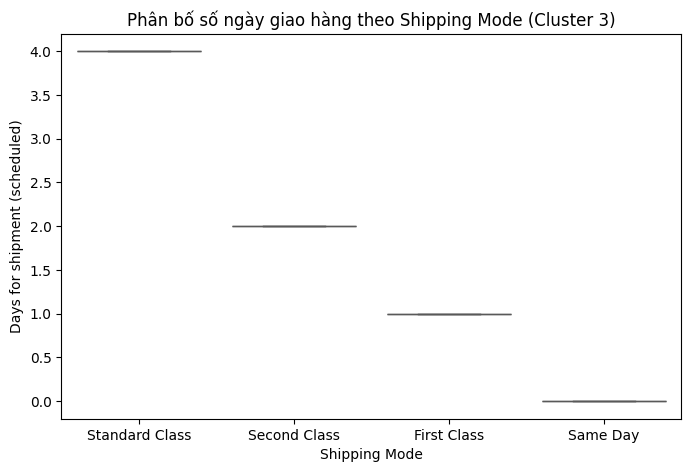

/tmp/ipython-input-2138993982.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_cluster3, x='Shipping Mode', y='Benefit per order', palette='Set3')
/tmp/ipython-input-2138993982.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_cluster3, x='Shipping Mode', y='Sales per customer', palette='Set3')


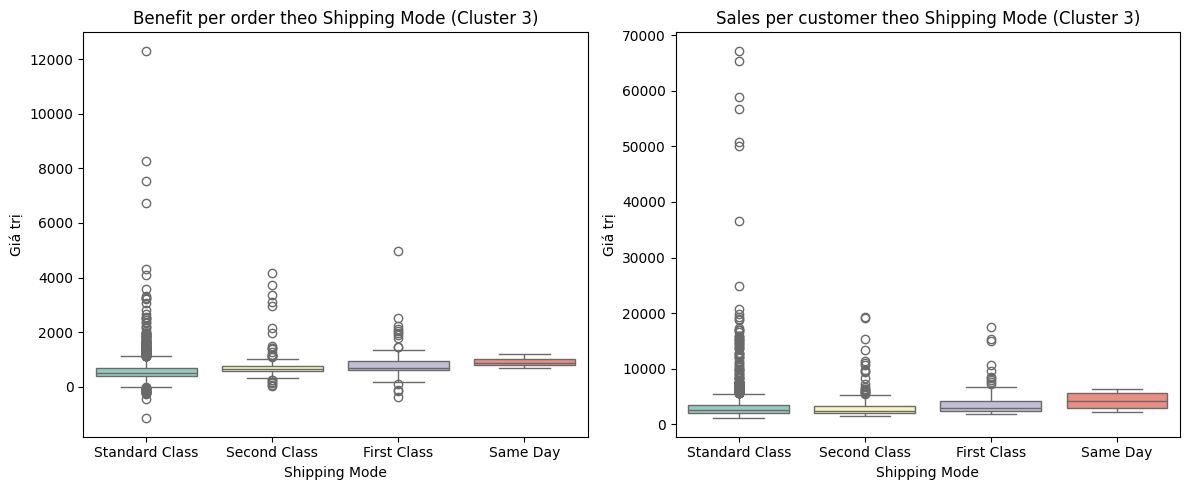

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Lọc dữ liệu cluster 3 ---
df_cluster3 = df_phancum[df_phancum['Cluster'] == 3].copy()

# --- 1️ Phân bố số ngày theo Shipping Mode ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster3, x='Shipping Mode', y='Days for shipment (scheduled)', palette='Set2')
plt.title('Phân bố số ngày giao hàng theo Shipping Mode (Cluster 3)')
plt.ylabel('Days for shipment (scheduled)')
plt.xlabel('Shipping Mode')
plt.show()

# --- 2️ So sánh lợi nhuận và doanh số ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], data=df_cluster3, x='Shipping Mode', y='Benefit per order', palette='Set3')
axes[0].set_title('Benefit per order theo Shipping Mode (Cluster 3)')

sns.boxplot(ax=axes[1], data=df_cluster3, x='Shipping Mode', y='Sales per customer', palette='Set3')
axes[1].set_title('Sales per customer theo Shipping Mode (Cluster 3)')

for ax in axes:
    ax.set_xlabel('Shipping Mode')
    ax.set_ylabel('Giá trị')

plt.tight_layout()
plt.show()

Có cả 4 phương thức trong cụm nhưng Stanrd Class chiếm nhiều nhất

/tmp/ipython-input-3573490970.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')


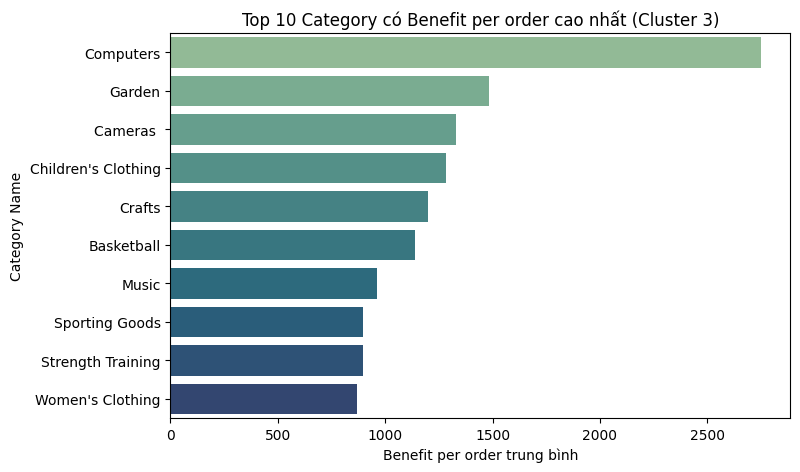

In [ ]:
top10_benefit = (
    df_cluster3.groupby('Category Name')['Benefit per order']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_benefit.values, y=top10_benefit.index, palette='crest')
plt.title('Top 10 Category có Benefit per order cao nhất (Cluster 3)')
plt.xlabel('Benefit per order trung bình')
plt.ylabel('Category Name')
plt.show()

Computers có số lượng lợi nhuận cao nhất

/tmp/ipython-input-1506078122.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_sale.values, y=top10_sale.index, palette='crest')


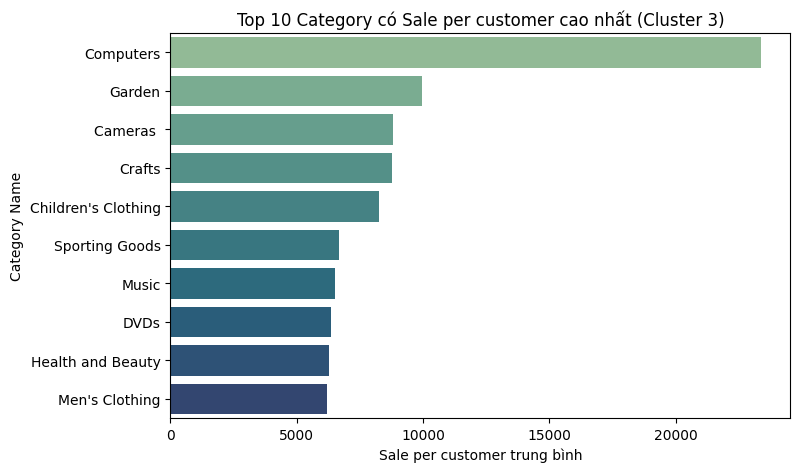

In [ ]:
top10_sale = (
    df_cluster3.groupby('Category Name')['Sales per customer']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_sale.values, y=top10_sale.index, palette='crest')
plt.title('Top 10 Category có Sale per customer cao nhất (Cluster 3)')
plt.xlabel('Sale per customer trung bình')
plt.ylabel('Category Name')
plt.show()


Computers là nhóm có Sale per customer cao nhất

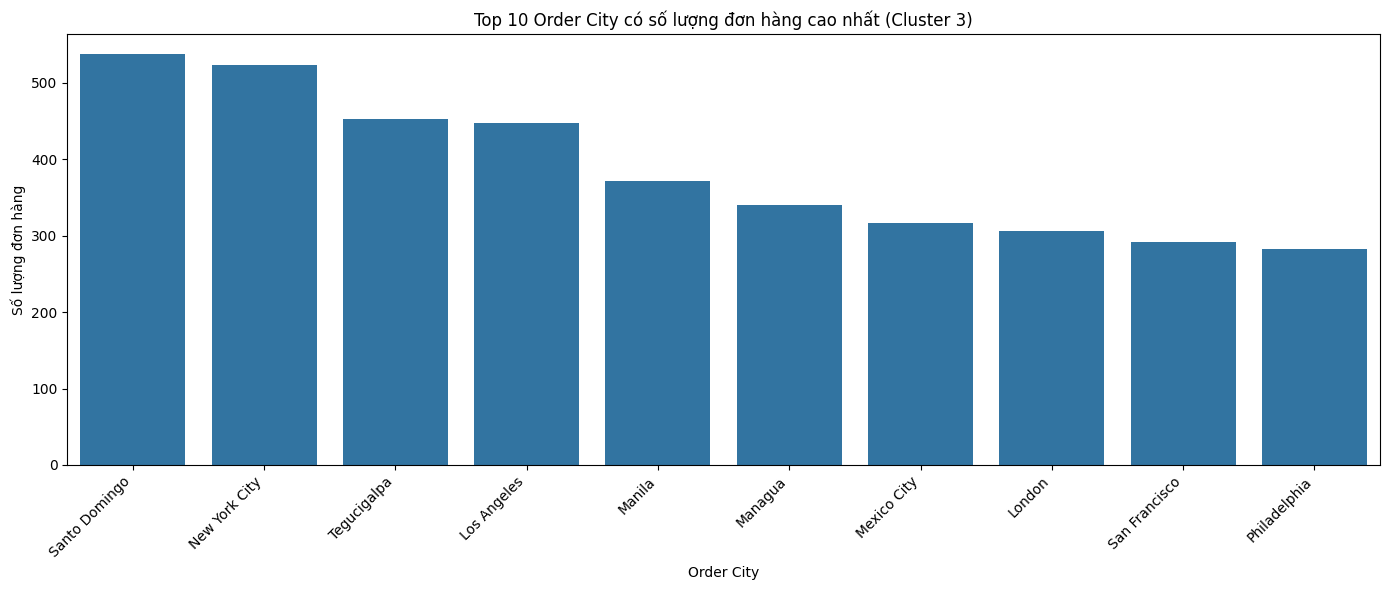

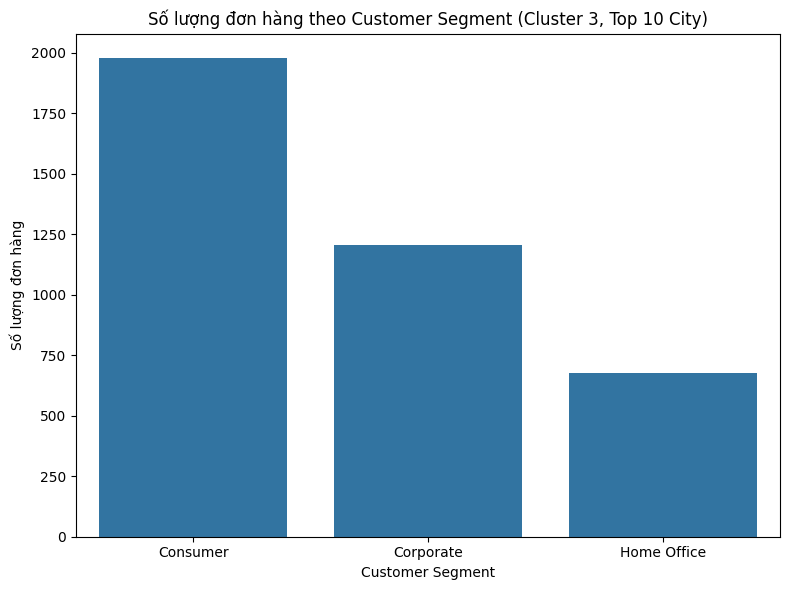

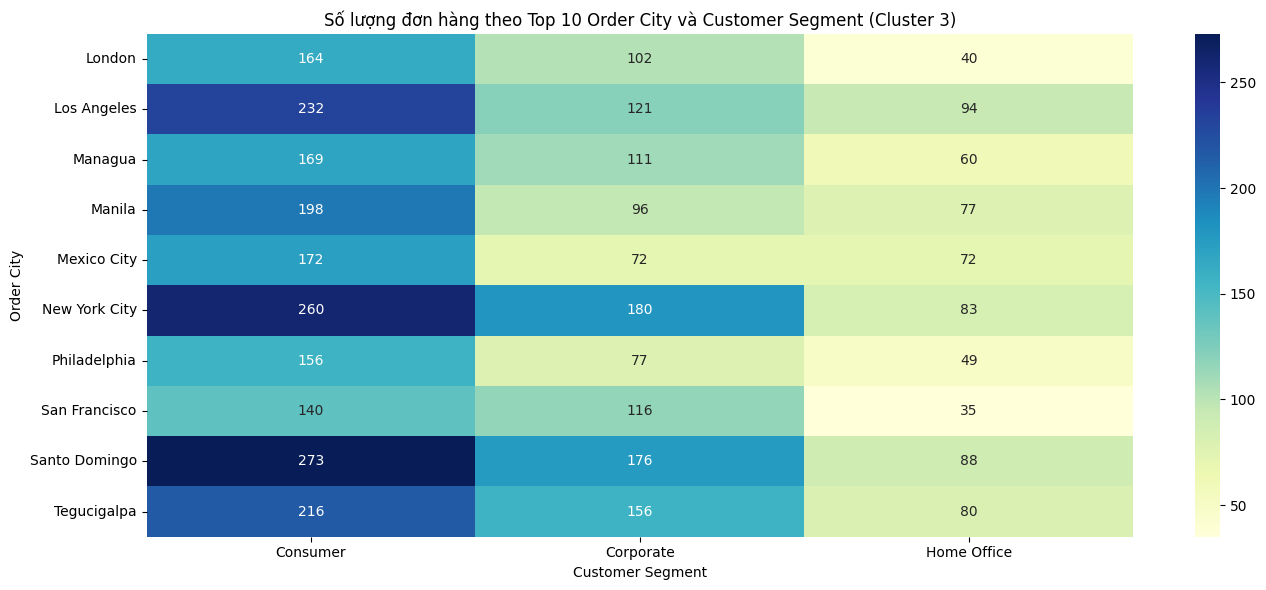

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Lọc Cluster 3 ---
df_cluster3 = df_phancum[df_phancum['Cluster'] == 3].copy()

# --- Nổ list thành từng dòng riêng cho Order City và Customer Segment ---
df_exploded = df_cluster3.explode(['Order City', 'Customer Segment'])

# --- Lấy Top 10 Order City có nhiều đơn hàng nhất ---
top10_cities = df_exploded['Order City'].value_counts().nlargest(10).index
df_top10 = df_exploded[df_exploded['Order City'].isin(top10_cities)]

# --- Biểu đồ 1: Số lượng đơn hàng theo Top 10 Order City ---
plt.figure(figsize=(14,6))
sns.countplot(data=df_top10, x='Order City', order=top10_cities)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Order City có số lượng đơn hàng cao nhất (Cluster 3)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Order City')
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: Số lượng đơn hàng theo Customer Segment ---
plt.figure(figsize=(8,6))
sns.countplot(data=df_top10, x='Customer Segment', order=df_top10['Customer Segment'].value_counts().index)
plt.title('Số lượng đơn hàng theo Customer Segment (Cluster 3, Top 10 City)')
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

# --- Biểu đồ 3: Heatmap kết hợp Top 10 Order City và Customer Segment ---
city_segment_table = pd.crosstab(df_top10['Order City'], df_top10['Customer Segment'])
plt.figure(figsize=(14,6))
sns.heatmap(city_segment_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Số lượng đơn hàng theo Top 10 Order City và Customer Segment (Cluster 3)')
plt.ylabel('Order City')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()


Santo Dominggo, New York  City là 2 nơi có điểm đến đơn hàng cao nhất; Consumer là phân khúc khách hàng đông nhất

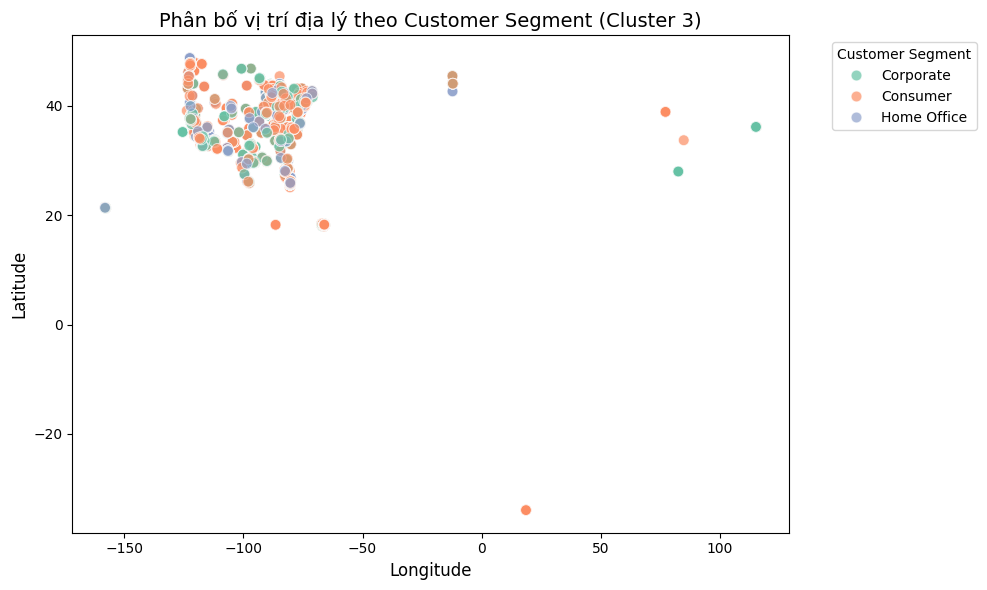

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sao chép cluster 3 ---
df_cluster3 = df_phancum[df_phancum['Cluster'] == 3].copy()

# --- Chuyển từ string list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

df_cluster3['Latitude'] = df_cluster3['Latitude'].apply(safe_eval)
df_cluster3['Longitude'] = df_cluster3['Longitude'].apply(safe_eval)
df_cluster3['Customer Segment'] = df_cluster3['Customer Segment'].apply(safe_eval)

# --- Gộp lại thành list các tuple (lat, long) ---
df_cluster3['Coords'] = df_cluster3.apply(lambda row: list(zip(row['Latitude'], row['Longitude'])), axis=1)

# --- Explode cả Coords và Customer Segment ---
df_cluster3 = df_cluster3.explode(['Coords', 'Customer Segment']).reset_index(drop=True)

# --- Tách lại ra 2 cột Latitude/Longitude ---
df_cluster3['Latitude'] = df_cluster3['Coords'].apply(lambda x: x[0])
df_cluster3['Longitude'] = df_cluster3['Coords'].apply(lambda x: x[1])

# --- Xóa cột Coords dư ---
df_cluster3.drop(columns=['Coords'], inplace=True)

# --- Vẽ scatterplot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster3,
    x='Longitude',
    y='Latitude',
    hue='Customer Segment',
    alpha=0.7,
    s=60,
    palette='Set2'
)
plt.title('Phân bố vị trí địa lý theo Customer Segment (Cluster 3)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Phân khúc khách hàng tập trung trong kinh độ -130, -70; vĩ độ 20-40 độ trải dài trên 3 phân khúc khách hàng

# Description about geography


=== Bảng tọa độ trung bình mỗi cụm ===
   Customer Segment   Latitude  Longitude  Cluster
0          Consumer  29.850135 -84.809308        0
1         Corporate  29.843193 -85.052285        0
2       Home Office  29.593826 -84.826750        0
3          Consumer  29.668271 -84.770731        1
4         Corporate  29.702350 -84.991412        1
5       Home Office  29.657668 -84.741507        1
6          Consumer  29.799912 -85.059999        2
7         Corporate  29.709865 -84.950786        2
8       Home Office  29.616335 -85.125441        2
9          Consumer  29.697937 -84.925813        3
10        Corporate  29.709089 -84.986473        3
11      Home Office  29.724715 -85.007670        3


TypeError: Axes.annotate() missing 1 required positional argument: 'text'

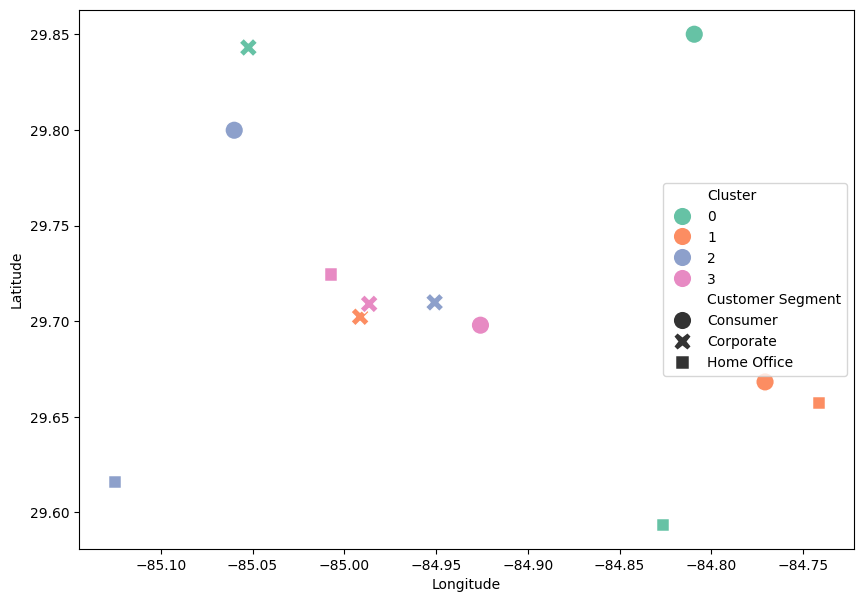

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Chuyển chuỗi list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

# --- Lấy trung bình nếu là list ---
def avg_list(x):
    if isinstance(x, list):
        try:
            return np.mean([float(i) for i in x])
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

# --- Lưu kết quả từng Cluster ---
cluster_means = []

for c in sorted(df_phancum['Cluster'].unique()):
    df_cluster = df_phancum[df_phancum['Cluster'] == c].copy()

    # Chuyển các cột có list sang dạng thực
    for col in ['Latitude', 'Longitude', 'Customer Segment']:
        df_cluster[col] = df_cluster[col].apply(safe_eval)

    # Nổ Customer Segment thành từng dòng
    df_cluster = df_cluster.explode('Customer Segment').reset_index(drop=True)

    # Tính trung bình Latitude/Longitude nếu là list
    df_cluster['Latitude'] = df_cluster['Latitude'].apply(avg_list)
    df_cluster['Longitude'] = df_cluster['Longitude'].apply(avg_list)

    # Bỏ NaN
    df_cluster = df_cluster.dropna(subset=['Latitude', 'Longitude', 'Customer Segment'])

    # Tính trung bình theo Customer Segment
    grouped = df_cluster.groupby('Customer Segment', as_index=False)[['Latitude', 'Longitude']].mean()
    grouped['Cluster'] = c
    cluster_means.append(grouped)

# --- Ghép tất cả cụm ---
df_means = pd.concat(cluster_means, ignore_index=True)
df_means['Latitude'] = df_means['Latitude'].astype(float)
df_means['Longitude'] = df_means['Longitude'].astype(float)

print("\n=== Bảng tọa độ trung bình mỗi cụm ===")
print(df_means)

# --- Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=df_means,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    style='Customer Segment',
    s=180,
    palette='Set2',
    ax=ax,
    zorder=2
)

# --- Annotation ---
for _, row in df_means.iterrows():
    ax.annotate(
        #f"C{int(row['Cluster'])} - {row['Customer Segment']}\n({row['Latitude']:.2f}, {row['Longitude']:.2f})",
        xy=(row['Longitude'], row['Latitude']),
        xytext=(5, 5),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        zorder=5
    )

# --- Cấu hình hiển thị ---
ax.set_title('Tọa độ trung bình theo Cluster và Customer Segment', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Chú thích
legend = ax.legend(title='Cluster / Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
for text in legend.get_texts():
    text.set_fontsize(9)

plt.tight_layout()
plt.show()


Mỗi phân khúc khách hàng có của từng cụm ở một nơi khác nhau--> chứng tỏ có sự chênh lệch có thể chấp nhận được giữa những phân khúc khách hàng


=== Tọa độ trung bình từng Cluster ===
   Cluster   Latitude  Longitude
0        0  29.867872 -85.225871
1        1  29.720627 -84.960885
2        2  29.801341 -85.104660
3        3  29.689705 -84.968217


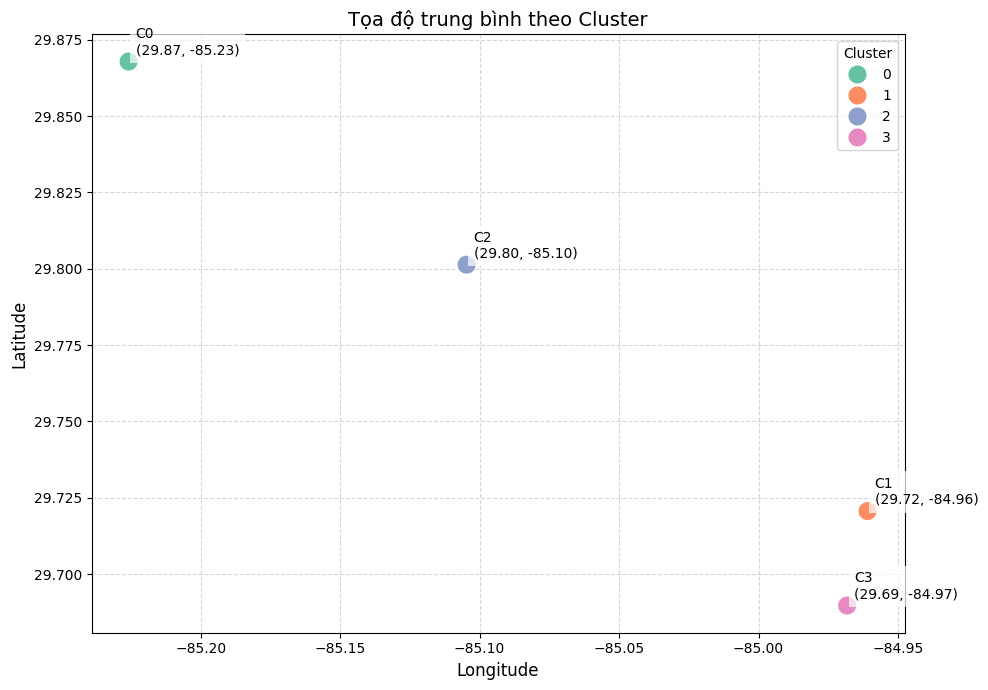

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Chuyển chuỗi list sang list thực ---
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

# --- Lấy trung bình nếu là list ---
def avg_list(x):
    if isinstance(x, list):
        try:
            return np.mean([float(i) for i in x])
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

# --- Lưu kết quả từng Cluster ---
cluster_means = []

for c in sorted(df_phancum['Cluster'].unique()):
    df_cluster = df_phancum[df_phancum['Cluster'] == c].copy()

    # Chuyển các cột Latitude/Longitude sang dạng thực
    for col in ['Latitude', 'Longitude']:
        df_cluster[col] = df_cluster[col].apply(safe_eval)
        df_cluster[col] = df_cluster[col].apply(avg_list)

    # Bỏ NaN
    df_cluster = df_cluster.dropna(subset=['Latitude', 'Longitude'])

    # Tính trung bình theo Cluster
    mean_lat = df_cluster['Latitude'].mean()
    mean_lon = df_cluster['Longitude'].mean()
    cluster_means.append({'Cluster': c, 'Latitude': mean_lat, 'Longitude': mean_lon})

# --- Tạo DataFrame kết quả ---
df_means = pd.DataFrame(cluster_means)

print("\n=== Tọa độ trung bình từng Cluster ===")
print(df_means)

# --- Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=df_means,
    x='Longitude',
    y='Latitude',
    hue='Cluster',
    s=200,
    palette='Set2',
    ax=ax,
    legend='full',
    zorder=2
)

# --- Annotation ---
for _, row in df_means.iterrows():
    ax.annotate(
        f"C{int(row['Cluster'])}\n({row['Latitude']:.2f}, {row['Longitude']:.2f})",
        xy=(row['Longitude'], row['Latitude']),
        xytext=(5, 5),
        textcoords='offset points',
        ha='left',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        zorder=5
    )

# --- Cấu hình hiển thị ---
ax.set_title('Tọa độ trung bình theo Cluster', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Mỗi tọa độ  ứng vợi 1 cluster 1 khu vực --> khả năng giải thích từng cụm ở từng địa điểm vị trí địa lí

# Caculate average cluster delay probability

In [ ]:
import os
import pickle
import pandas as pd
import gc

model_files = {
    "ExtraTrees": "/content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/extratrees_resampling.pkl",
}

models_ros = {}

for name, path in model_files.items():
    print(f"\n Đang load {name} từ {path} ...")

    if not os.path.exists(path):
        print(f" Không tìm thấy file: {path}")
        continue

    try:
        with open(path, "rb") as f:
            pkg = pickle.load(f)
        print(f" File {name} load thành công")

        # Kiểm tra cấu trúc và lấy encoder, scaler, model
        encoder = pkg.get("encoder")
        scaler = pkg.get("scaler")
        model = pkg.get("models", {}).get(name, {}).get("ROS")

        if encoder is None or scaler is None or model is None:
            print(f" Thiếu encoder/scaler/model trong {name}, bỏ qua.")
            continue

        models_ros[name] = {
            "encoder": encoder,
            "scaler": scaler,
            "model": model
        }
        print(f" Loaded {name} ROS hoàn chỉnh")

    except (EOFError, AttributeError, MemoryError, pickle.UnpicklingError) as e:
        print(f" Lỗi khi load {name}: {type(e).__name__} - {e}")
        continue
    except Exception as e:
        print(f" Lỗi không xác định khi load {name}: {e}")
        continue

    del pkg
    gc.collect()


 Đang load ExtraTrees từ /content/drive/Shareddrives/Học máy trong kinh doanh/MODEL/RESULT_PHASE1/extratrees_resampling.pkl ...
 File ExtraTrees load thành công
 Loaded ExtraTrees ROS hoàn chỉnh


In [ ]:
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk,order date (DateOrders),Predicted_Label,Prob_NotLate,Prob_Late,Day
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,0.04,327.750000,0.29,1,0,2018-01-31 22:56:00,Trễ,0.45,0.55,2018-01-31
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,0.05,327.750000,-0.80,1,1,2018-01-13 12:27:00,Không trễ,0.54,0.46,2018-01-13
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,0.06,327.750000,-0.80,1,0,2018-01-13 12:06:00,Không trễ,0.59,0.41,2018-01-13
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,0.07,327.750000,0.08,1,0,2018-01-13 11:45:00,Không trễ,0.52,0.48,2018-01-13
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,0.09,327.750000,0.45,1,0,2018-01-13 11:24:00,Trễ,0.49,0.51,2018-01-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,0.00,399.980011,0.10,1,0,2016-01-16 03:40:00,Không trễ,0.60,0.40,2016-01-16
180515,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,0.01,399.980011,-1.55,1,1,2016-01-16 01:34:00,Trễ,0.22,0.78,2016-01-16
180516,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,0.02,399.980011,0.36,1,1,2016-01-15 21:00:00,Không trễ,0.57,0.43,2016-01-15
180517,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,0.03,399.980011,0.48,1,0,2016-01-15 20:18:00,Không trễ,0.51,0.49,2016-01-15


In [ ]:
def normalize_input(input_dict):
    cleaned = {}
    for k, v in input_dict.items():
        if isinstance(v, str):
            cleaned[k] = v.strip().title()  # bỏ khoảng trắng + viết hoa đầu từ
        else:
            cleaned[k] = v
    return cleaned

In [ ]:
from scipy.sparse import hstack
import pandas as pd

def predict_df_fast(model_package, df_selected, selected_numerical_features_trong, selected_categorical_features_trong):
    """
    Dự đoán toàn bộ DataFrame df_selected bằng model đã load
    và gộp kết quả dự đoán vào df_selected.
    """

    encoder = model_package["encoder"]
    model = model_package["model"]

    # === 1. Chuẩn bị dữ liệu ===
    X_num = df_selected[selected_numerical_features_trong].values
    X_cate = encoder.transform(df_selected[selected_categorical_features_trong])
    X_all = hstack((X_num, X_cate))

    # === 2. Dự đoán ===
    preds = model.predict(X_all)
    probs = model.predict_proba(X_all)

    # === 3. Thêm kết quả vào DataFrame gốc ===
    df_selected["Predicted_Label"] = ["Trễ" if p == 1 else "Không trễ" for p in preds]
    df_selected["Prob_NotLate"] = probs[:, 0]
    df_selected["Prob_Late"] = probs[:, 1]

    print(" Dự đoán hoàn tất và đã gộp vào df_selected!")
    print(df_selected[["Predicted_Label", "Prob_NotLate", "Prob_Late"]].head())

    return df_selected


In [ ]:
model_info = models_ros["ExtraTrees"]

df_selected = predict_df_fast(
    model_info,
    df_selected,
    selected_numerical_features_trong,
    selected_categorical_features_trong
)


 Dự đoán hoàn tất và đã gộp vào df_selected!
  Predicted_Label  Prob_NotLate  Prob_Late
0             Trễ          0.45       0.55
1       Không trễ          0.54       0.46
2       Không trễ          0.59       0.41
3       Không trễ          0.52       0.48
4             Trễ          0.49       0.51


Xác suất từng đơn trễ như hình dưới ở cột Prob_Late

In [ ]:
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk,order date (DateOrders),Predicted_Label,Prob_NotLate,Prob_Late,Day
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,0.04,327.750000,0.29,1,0,2018-01-31 22:56:00,Trễ,0.45,0.55,2018-01-31
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,0.05,327.750000,-0.80,1,1,2018-01-13 12:27:00,Không trễ,0.54,0.46,2018-01-13
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,0.06,327.750000,-0.80,1,0,2018-01-13 12:06:00,Không trễ,0.59,0.41,2018-01-13
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,0.07,327.750000,0.08,1,0,2018-01-13 11:45:00,Không trễ,0.52,0.48,2018-01-13
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,0.09,327.750000,0.45,1,0,2018-01-13 11:24:00,Trễ,0.49,0.51,2018-01-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,0.00,399.980011,0.10,1,0,2016-01-16 03:40:00,Không trễ,0.60,0.40,2016-01-16
180515,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,0.01,399.980011,-1.55,1,1,2016-01-16 01:34:00,Trễ,0.22,0.78,2016-01-16
180516,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,0.02,399.980011,0.36,1,1,2016-01-15 21:00:00,Không trễ,0.57,0.43,2016-01-15
180517,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,0.03,399.980011,0.48,1,0,2016-01-15 20:18:00,Không trễ,0.51,0.49,2016-01-15


Vấn đề merge  trong df_phancum theo 3 trường nhưng merge theo các tiêu chí khác để phân cụm thì lại khác số dòng có những dòng bị null vì không có xác suất trễ khi merge lại

In [ ]:
# Chọn 4 cột cần thiết
cols_keep = ['Day', 'Category Name', 'Shipping Mode', 'Cluster']

# Tạo df_phancummoi
df_phancummoi = df_phancum[cols_keep].copy()

# Kiểm tra kết quả
df_phancummoi


,Day,Category Name,Shipping Mode,Cluster
0,2015-01-01,Accessories,First Class,2
1,2015-01-01,Accessories,Second Class,0
2,2015-01-01,Accessories,Standard Class,1
3,2015-01-01,Baseball & Softball,First Class,2
4,2015-01-01,Camping & Hiking,First Class,2
...,...,...,...,...
40891,2018-01-31,Toys,Standard Class,1
40892,2018-01-31,Video Games,Same Day,2
40893,2018-01-31,Women's Clothing,First Class,2
40894,2018-01-31,Women's Clothing,Second Class,0


Merge thêm cột Cluster vào data ban đầu theo 3 khóa chính để tính xác suất trung bình

In [ ]:
# Merge cột Cluster từ df_phancummoi vào df_selected
df_selected = df_selected.merge(
    df_phancummoi[['Day', 'Category Name', 'Shipping Mode', 'Cluster']],
    on=['Day', 'Category Name', 'Shipping Mode'],
    how='left'  # giữ nguyên tất cả dòng df_selected
)

# Kiểm tra kết quả
df_selected

,Department Name,Category Name,Customer State,Order Status,Order Country,Order Region,Order State,Type,Customer City,Order City,...,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Late_delivery_risk,order date (DateOrders),Predicted_Label,Prob_NotLate,Prob_Late,Day,Cluster
0,Fitness,Sporting Goods,PR,COMPLETE,Indonesia,Southeast Asia,Java Occidental,DEBIT,Caguas,Bekasi,...,327.750000,0.29,1,0,2018-01-31 22:56:00,Trễ,0.45,0.55,2018-01-31,1
1,Fitness,Sporting Goods,PR,PENDING,India,South Asia,Rajastán,TRANSFER,Caguas,Bikaner,...,327.750000,-0.80,1,1,2018-01-13 12:27:00,Không trễ,0.54,0.46,2018-01-13,1
2,Fitness,Sporting Goods,CA,CLOSED,India,South Asia,Rajastán,CASH,San Jose,Bikaner,...,327.750000,-0.80,1,0,2018-01-13 12:06:00,Không trễ,0.59,0.41,2018-01-13,1
3,Fitness,Sporting Goods,CA,COMPLETE,Australia,Oceania,Queensland,DEBIT,Los Angeles,Townsville,...,327.750000,0.08,1,0,2018-01-13 11:45:00,Không trễ,0.52,0.48,2018-01-13,1
4,Fitness,Sporting Goods,PR,PENDING_PAYMENT,Australia,Oceania,Queensland,PAYMENT,Caguas,Townsville,...,327.750000,0.45,1,0,2018-01-13 11:24:00,Trễ,0.49,0.51,2018-01-13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172760,Fan Shop,Fishing,NY,CLOSED,China,Eastern Asia,Shanghái,CASH,Brooklyn,Shanghái,...,399.980011,0.10,1,0,2016-01-16 03:40:00,Không trễ,0.60,0.40,2016-01-16,3
172761,Fan Shop,Fishing,CA,COMPLETE,Japón,Eastern Asia,Osaka,DEBIT,Bakersfield,Hirakata,...,399.980011,-1.55,1,1,2016-01-16 01:34:00,Trễ,0.22,0.78,2016-01-16,0
172762,Fan Shop,Fishing,CT,PENDING,Australia,Oceania,Australia del Sur,TRANSFER,Bristol,Adelaide,...,399.980011,0.36,1,1,2016-01-15 21:00:00,Không trễ,0.57,0.43,2016-01-15,3
172763,Fan Shop,Fishing,PR,PENDING_PAYMENT,Australia,Oceania,Australia del Sur,PAYMENT,Caguas,Adelaide,...,399.980011,0.48,1,0,2016-01-15 20:18:00,Không trễ,0.51,0.49,2016-01-15,3


In [ ]:
# Kiểm tra số dòng bị null ở từng cột
print("Số dòng null cột Prob_Late:", df_selected['Prob_Late'].isna().sum())
print("Số dòng null cột Cluster:", df_selected['Cluster'].isna().sum())

# Xem chi tiết các dòng có null ở một trong hai cột
df_null = df_selected[df_selected['Prob_Late'].isna() | df_selected['Cluster'].isna()]
print("Tổng số dòng bị null ở Prob_Late hoặc Cluster:", len(df_null))

# In ra các dòng bị null
df_null[['Day', 'Category Name', 'Shipping Mode', 'Prob_Late', 'Cluster']]


Số dòng null cột Prob_Late: 0
Số dòng null cột Cluster: 0
Tổng số dòng bị null ở Prob_Late hoặc Cluster: 0


,Day,Category Name,Shipping Mode,Prob_Late,Cluster


In [ ]:
# Tính trung bình Prob_Late theo từng cụm
cluster_prob_mean = (
    df_selected.groupby('Cluster')['Prob_Late']
    .mean()
    .reset_index()
    .rename(columns={'Prob_Late': 'Prob_Late_mean'})
)
# Hiển thị kết quả
print(cluster_prob_mean)


   Cluster  Prob_Late_mean
0        0        0.754393
1        1        0.452849
2        2        0.761273
3        3        0.473722



*   Xác xuất trễ trung bình cụm 0: 0,75

*   Xác xuất trễ trung bình cụm 1: 0,45

*   Xác xuất trễ trung bình cụm 2: 0,76

*   Xác xuất trễ trung bình cụm 3: 0,47







*   Cluster 0 và Cluster 2 có xác suất trễ cao (0.75 – 0.76)
Nghĩa là các đơn hàng thuộc nhóm này rất dễ bị trễ, chiếm khoảng 3/4 khả năng trễ. Bởi vì do số ngày giao hàng dự kiến ít nên rất dễ bị giao trễ. Đây có thể là những Category / Shipping Mode / ngày giao hàng khó quản lý, hoặc các đơn hàng có số lượng, khoảng cách vận chuyển, hoặc lịch trình phức tạp.

*   Cluster 1 và Cluster 3 có xác suất trễ thấp (0.45 – 0.47)
Các đơn hàng thuộc nhóm này tương đối ít bị trễ, dưới 50%. Do thuộc nhóm giao hàng tiêu chuẩn dự kiến 4 ngày --> nên khả năng trễ sẽ thấp hơn. Đây có thể là những đơn hàng có quy trình vận chuyển ổn định, khoảng cách ngắn, hoặc Category dễ xử lý.


*   Giải pháp: Cluster 2 và Cluster 0 → cần ưu tiên theo dõi và can thiệp để giảm trễ. Cluster 1 và Cluster 3 → các đơn hàng này có thể được coi là ổn định, ít rủi ro hơn.



*   Ứng dụng thực tế: Có thể tập trung nguồn lực, nhân sự, hoặc tối ưu lịch trình cho Cluster 0 và 2. Cluster 1 và 3 có thể duy trì quy trình hiện tại, ít cần can thiệp.